# Three-Perspective Thematic Comparison of ML-OPF Research

## 1. Setup and Paths

This notebook integrates the final topic-modeling outputs from the academic
Scopus corpus, the patent-cited corpus, and the policy-cited corpus.

No LDA models are estimated in this notebook. Instead, previously estimated
topic models are loaded, harmonized into a common macro-theme taxonomy, and
compared across the three research perspectives.

The three perspectives are:

- **Academic research:** full Scopus ML--OPF corpus.
- **Patent-cited research:** Scopus publications identified as cited by patents through Lens.
- **Policy-cited research:** Scopus publications identified as cited by policy documents through Overton.

The final objective is to construct a common thematic comparison of academic,
patent, and policy perspectives using probability-weighted topic prevalence.

In [32]:
# ---------------------------------------------------------
# Imports
# ---------------------------------------------------------

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [33]:
# ---------------------------------------------------------
# Project directories
# ---------------------------------------------------------

PROJECT_DIR = Path.home() / "project" / "review_paper_fahruddin"


DATA_DIR = (
    PROJECT_DIR
    / "data"
)


OUTPUT_DIR = (
    PROJECT_DIR
    / "output"
)


FIGURE_DIR = (
    PROJECT_DIR
    / "figs"
)


# ---------------------------------------------------------
# Existing topic-modeling output directories
# ---------------------------------------------------------

PATENT_POLICY_TOPIC_DIR = (
    OUTPUT_DIR
    / "patent_policy_topic_modeling"
)


PATENT_POLICY_LDA_DIR = (
    PATENT_POLICY_TOPIC_DIR
    / "lda"
)
# ---------------------------------------------------------
# Inspect existing output directories
# ---------------------------------------------------------

print(
    "Project directory:",
    PROJECT_DIR
)


print(
    "Output directory:",
    OUTPUT_DIR
)


print()
print(
    "Output subdirectories:"
)


for path in sorted(
    OUTPUT_DIR.iterdir()
):

    if path.is_dir():

        print(
            " -",
            path.name
        )

Project directory: /nfs/mfirdausi/project/review_paper_fahruddin
Output directory: /nfs/mfirdausi/project/review_paper_fahruddin/output

Output subdirectories:
 - academic_patent_policy_comparison
 - patent_policy_citation_landscape
 - patent_policy_topic_modeling
 - scopus_research_landscape


In [34]:
# ---------------------------------------------------------
# Three-perspective comparison output
# ---------------------------------------------------------

THREE_PERSPECTIVE_DIR = (
    OUTPUT_DIR
    / "academic_patent_policy_comparison"
)


TABLE_DIR = (
    THREE_PERSPECTIVE_DIR
    / "tables"
)


COMPARISON_FIGURE_DIR = (
    THREE_PERSPECTIVE_DIR
    / "figures"
)


THREE_PERSPECTIVE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


COMPARISON_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


print(
    "Comparison output:",
    THREE_PERSPECTIVE_DIR
)


print(
    "Tables:",
    TABLE_DIR
)


print(
    "Figures:",
    COMPARISON_FIGURE_DIR
)

Comparison output: /nfs/mfirdausi/project/review_paper_fahruddin/output/academic_patent_policy_comparison
Tables: /nfs/mfirdausi/project/review_paper_fahruddin/output/academic_patent_policy_comparison/tables
Figures: /nfs/mfirdausi/project/review_paper_fahruddin/output/academic_patent_policy_comparison/figures


In [35]:
# ---------------------------------------------------------
# Patent/policy final topic files
# ---------------------------------------------------------

PATENT_TOPIC_FILE = (
    PATENT_POLICY_LDA_DIR
    / "patent_cited_final_topic_interpretation.csv"
)


POLICY_TOPIC_FILE = (
    PATENT_POLICY_LDA_DIR
    / "policy_cited_final_topic_interpretation.csv"
)

PATENT_POLICY_MACRO_FILE = (
    PATENT_POLICY_LDA_DIR
    / "patent_policy_macro_theme_table.csv"
)

In [36]:
# ---------------------------------------------------------
# Validate known input files
# ---------------------------------------------------------

known_input_files = {

    "Patent topic interpretation":
        PATENT_TOPIC_FILE,

    "Policy topic interpretation":
        POLICY_TOPIC_FILE,

    "Patent-policy macro-theme table":
        PATENT_POLICY_MACRO_FILE,
}


for name, path in known_input_files.items():

    print(
        f"{name:<38}",
        "FOUND"
        if path.exists()
        else "MISSING",
    )

    print(
        "   ",
        path
    )

Patent topic interpretation            FOUND
    /nfs/mfirdausi/project/review_paper_fahruddin/output/patent_policy_topic_modeling/lda/patent_cited_final_topic_interpretation.csv
Policy topic interpretation            FOUND
    /nfs/mfirdausi/project/review_paper_fahruddin/output/patent_policy_topic_modeling/lda/policy_cited_final_topic_interpretation.csv
Patent-policy macro-theme table        FOUND
    /nfs/mfirdausi/project/review_paper_fahruddin/output/patent_policy_topic_modeling/lda/patent_policy_macro_theme_table.csv


In [37]:
# ---------------------------------------------------------
# Display settings
# ---------------------------------------------------------

pd.set_option(
    "display.max_columns",
    None,
)


pd.set_option(
    "display.max_colwidth",
    120,
)


pd.set_option(
    "display.width",
    200,
)

## 2. Load Final Academic Topic Results

The academic perspective is represented by the final \(K=50\) LDA model
estimated on the full Scopus ML--OPF corpus.

For the three-perspective comparison, the analysis returns to the 50
fine-grained academic topics rather than using the previously aggregated
academic macro-themes. Each academic topic will subsequently be mapped to
the same common macro-theme taxonomy used for the patent- and policy-cited
corpora.

The required information for each topic is:

- topic identifier;
- probability-weighted prevalence;
- manually assigned topic label;
- highest-probability terms; and
- representative publication titles.

In [38]:
# ---------------------------------------------------------
# Locate existing academic topic-modeling outputs
# ---------------------------------------------------------

print(
    "Searching for academic topic outputs..."
)

print()


candidate_files = []


for path in OUTPUT_DIR.rglob(
    "*.csv"
):

    name_lower = (
        path.name
        .lower()
    )

    if any(
        keyword in name_lower
        for keyword in [
            "topic",
            "prevalence",
            "interpret",
            "scopus",
            "academic",
        ]
    ):

        candidate_files.append(
            path
        )


for path in sorted(
    candidate_files
):

    print(
        path.relative_to(
            PROJECT_DIR
        )
    )

Searching for academic topic outputs...

output/academic_patent_policy_comparison/tables/academic_common_macro_theme_summary.csv
output/academic_patent_policy_comparison/tables/academic_patent_policy_common_macro_themes.csv
output/academic_patent_policy_comparison/tables/academic_patent_policy_common_macro_themes_long.csv
output/academic_patent_policy_comparison/tables/academic_patent_policy_external_amplification.csv
output/academic_patent_policy_comparison/tables/academic_patent_policy_pairwise_similarity.csv
output/academic_patent_policy_comparison/tables/academic_patent_policy_theme_consistency.csv
output/academic_patent_policy_comparison/tables/academic_topic_common_theme_coding_worksheet.csv
output/academic_patent_policy_comparison/tables/academic_topic_to_common_macro_theme.csv
output/academic_patent_policy_comparison/tables/academic_topics_standardized.csv
output/academic_patent_policy_comparison/tables/policy_topics_standardized.csv
output/patent_policy_topic_modeling/lda/pate

In [39]:
# ---------------------------------------------------------
# 2.1 Define academic LDA output directory
# ---------------------------------------------------------

ACADEMIC_LDA_DIR = (
    OUTPUT_DIR
    / "scopus_research_landscape"
    / "lda"
)


ACADEMIC_PREVALENCE_FILE = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_final_topic_prevalence.csv"
)


ACADEMIC_TOP_TERMS_FILE = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_final_top_terms.csv"
)


ACADEMIC_LABEL_FILE = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_topic_labeling.csv"
)


ACADEMIC_REPRESENTATIVE_FILE = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_final_representative_documents.csv"
)


academic_files = {
    "Topic prevalence":
        ACADEMIC_PREVALENCE_FILE,

    "Top terms":
        ACADEMIC_TOP_TERMS_FILE,

    "Topic labels":
        ACADEMIC_LABEL_FILE,

    "Representative documents":
        ACADEMIC_REPRESENTATIVE_FILE,
}


for name, path in academic_files.items():

    print(
        f"{name:<28}",
        "FOUND"
        if path.exists()
        else "MISSING"
    )

    print(
        "   ",
        path
    )

Topic prevalence             FOUND
    /nfs/mfirdausi/project/review_paper_fahruddin/output/scopus_research_landscape/lda/scopus_academic_final_topic_prevalence.csv
Top terms                    FOUND
    /nfs/mfirdausi/project/review_paper_fahruddin/output/scopus_research_landscape/lda/scopus_academic_final_top_terms.csv
Topic labels                 FOUND
    /nfs/mfirdausi/project/review_paper_fahruddin/output/scopus_research_landscape/lda/scopus_academic_topic_labeling.csv
Representative documents     FOUND
    /nfs/mfirdausi/project/review_paper_fahruddin/output/scopus_research_landscape/lda/scopus_academic_final_representative_documents.csv


In [40]:
# ---------------------------------------------------------
# 2.2 Load academic topic outputs
# ---------------------------------------------------------

academic_prevalence = pd.read_csv(
    ACADEMIC_PREVALENCE_FILE
)


academic_top_terms = pd.read_csv(
    ACADEMIC_TOP_TERMS_FILE
)


academic_labels = pd.read_csv(
    ACADEMIC_LABEL_FILE
)


academic_representative = pd.read_csv(
    ACADEMIC_REPRESENTATIVE_FILE
)

In [41]:
# ---------------------------------------------------------
# 2.3 Inspect academic topic-output schemas
# ---------------------------------------------------------

academic_tables = {
    "PREVALENCE":
        academic_prevalence,

    "TOP TERMS":
        academic_top_terms,

    "LABELS":
        academic_labels,

    "REPRESENTATIVE DOCUMENTS":
        academic_representative,
}


for name, df in academic_tables.items():

    print()
    print(
        "=" * 70
    )

    print(
        name
    )

    print(
        "=" * 70
    )

    print(
        "Rows:",
        len(df)
    )

    print(
        "Columns:",
        df.columns.tolist()
    )

    display(
        df.head(10)
    )


PREVALENCE
Rows: 50
Columns: ['K', 'Topic', 'Prevalence_Rank', 'Mean_Probability', 'Prevalence_Percent']


,K,Topic,Prevalence_Rank,Mean_Probability,Prevalence_Percent
0,50,2,1,0.023338,2.333787
1,50,23,2,0.022616,2.261644
2,50,45,3,0.021885,2.188477
3,50,3,4,0.021399,2.139865
4,50,11,5,0.021384,2.138417
5,50,36,6,0.021367,2.136749
6,50,39,7,0.021237,2.123663
7,50,29,8,0.021147,2.114728
8,50,43,9,0.021042,2.104183
9,50,46,10,0.021034,2.103433



TOP TERMS
Rows: 500
Columns: ['K', 'Topic', 'Rank', 'Term', 'Beta']


,K,Topic,Rank,Term,Beta
0,50,1,1,learn,0.119226
1,50,1,2,machin,0.094601
2,50,1,3,model,0.056063
3,50,1,4,regress,0.038926
4,50,1,5,accuraci,0.033358
5,50,1,6,support,0.031871
6,50,1,7,random,0.027380
7,50,1,8,featur,0.027349
8,50,1,9,algorithm,0.026401
9,50,1,10,vector,0.025809



LABELS
Rows: 50
Columns: ['Topic', 'Prevalence_Rank', 'Prevalence_Percent', 'Top_Terms', 'Representative_Titles', 'Topic_Label', 'Macro_Theme']


,Topic,Prevalence_Rank,Prevalence_Percent,Top_Terms,Representative_Titles,Topic_Label,Macro_Theme
0,2,1,2.333787,"shortterm, featur, deep, learn, lstm, long, memori, tempor, extract, accuraci",Spatiotemporal Co-Attention Hybrid Neural Network for Pedestrian Localization Based on 6D IMU | Multivariate Time Se...,Deep learning for spatiotemporal forecasting,Data-Driven Forecasting and Analysis
1,23,2,2.261644,"control, voltag, mpc, system, stabil, propos, strategi, regul, frequenc, convert",Decentralized model predictive hierarchical control strategy for islanded AC microgrids | Predictive direct virtual ...,"Voltage, frequency, and microgrid control","Grid Control, Monitoring, and Smart Systems"
2,45,3,2.188477,"develop, futur, polici, econom, sector, growth, countri, will, project, plan",Resource demand growth and sustainability due to increased world consumption | Trends of energy demand in the Middle...,"Energy policy, demand, and economic growth","Sustainability, Climate, and Energy Policy"
3,3,4,2.139865,"can, one, order, possibl, will, new, also, requir, larg, need",Integrated path towards geological storage | Renewable energy and transmission networks | Stochastic Processes in th...,Mixed research topics with generic language,Cross-Cutting and Mixed Topics
4,11,5,2.138417,"framework, integr, demonstr, across, robust, achiev, enabl, address, captur, enhanc",TriAlignNet: A triple-path cross-modality alignment framework for multimodal time series forecasting | Development s...,Integrated and multimodal learning frameworks,Data-Driven Forecasting and Analysis
5,36,6,2.136749,"build, comfort, thermal, occup, indoor, ventil, air, save, studi, hvac",Determination of optimum window to externalwall ratio for offices in a hot and humid climate | Numerical investigati...,Building energy use and thermal comfort,Buildings and Residential Energy Use
6,39,7,2.123663,"studi, sustain, research, environment, find, signific, advanc, contribut, insight, highlight",Advancing sustainable energy systems: A decade of SETA research contribution to sustainable development goals | Unpa...,Sustainability and environmental research,"Sustainability, Climate, and Energy Policy"
7,29,8,2.114728,"renew, storag, price, grid, market, cost, sourc, microgrid, flexibl, suppli","Microeconomic models of electricity storage: Price Forecasting, arbitrage limits, curtailment insurance, and transmi...","Renewable energy, storage, and electricity markets","Renewable Energy, Storage, and Power-System Planning"
8,43,9,2.104183,"heat, temperatur, thermal, cool, air, condit, pump, perform, hot, exchang",Performance prediction on a novel dual-mode heat pump with a hybrid photovoltaic/micro-channel heat pipe/fin heat ex...,"Heat pumps, cooling, and heat transfer","Thermal, Fuel, and Industrial Processes"
9,46,10,2.103433,"flow, transfer, numer, experiment, pressur, simul, rate, fluid, mass, investig",Numerical Investigation of Slurry Pressure Drop at Different Pipe Roughness in a Straight Pipe Using CFD | Numerical...,Fluid flow and numerical heat-transfer analysis,"Thermal, Fuel, and Industrial Processes"



REPRESENTATIVE DOCUMENTS
Rows: 250
Columns: ['K', 'Topic', 'Rank', 'Document_ID', 'Topic_Probability', 'Title', 'Year', 'DOI', 'Abstract']


,K,Topic,Rank,Document_ID,Topic_Probability,Title,Year,DOI,Abstract
0,50,1,1,44373,0.342723,Comparison of machine-learning models for predicting short-term building heating load using operational parameters,2021,10.1016/j.enbuild.2021.111505,Short-term building energy consumption prediction is of great significance to the optimal operation of building ener...
1,50,1,2,35122,0.304636,Improving the prediction of wind speed and power production of SCADA system with ensemble method and 10-fold cross-v...,2023,10.1016/j.cscee.2023.100351,This research used machine-learning-based forecasting models to estimate a Supervisory control and data acquisition ...
2,50,1,3,11496,0.293413,Analysing feature selection: impacts towards forecasting electricity power consumption,2025,10.11591/ijres.v14.i1.pp265-272,"This study focuses on the development of electrical power forecasting based on electricity usage in Wuzhou, China. T..."
3,50,1,4,10209,0.288043,Integrating machine learning-based classification and regression models for solvent regeneration prediction in post-...,2025,10.1016/j.rineng.2025.104856,"As an industrialized nation with substantial greenhouse gas emissions, Iran faces an urgent need to implement post-c..."
4,50,1,5,42342,0.283721,Evaluation of Various Tree-Based Ensemble Models for Estimating Solar Energy Resource Potential in Different Climati...,2022,10.3390/en15093463,Solar photovoltaic (PV) electricity generation is growing rapidly in China. Accurate estimation of solar energy reso...
5,50,2,1,39588,0.391791,Spatiotemporal Co-Attention Hybrid Neural Network for Pedestrian Localization Based on 6D IMU,2023,10.1109/TASE.2022.3164966,"In this paper, we propose spatiotemporal co-attention hybrid neural network (SC-HNN), a novel hybrid neural network ..."
6,50,2,2,42332,0.374408,Multivariate Time Series Deep Spatiotemporal Forecasting with Graph Neural Network,2022,10.3390/app12115731,"Multivariate time series forecasting has long been a subject of great concern. For example, there are many valuable ..."
7,50,2,3,10543,0.362745,AutoGRN: An adaptive multi-channel graph recurrent joint optimization network with Copula-based dependency modeling ...,2025,10.1016/j.inffus.2024.102836,"Multi-sensor, multi-source information fusion presents significant challenges in complex real-world applications suc..."
8,50,2,4,14942,0.333333,Multiscale graph based spatio-temporal graph convolutional network for energy consumption prediction of natural gas ...,2024,10.1016/j.energy.2024.132489,"Energy consumption prediction is crucial for planning and managing natural gas networks, enhancing transmission effi..."
9,50,2,5,5044,0.327778,Short-Term Power Load Forecasting Based on GJO-TCN-BiGRU-TPA,2026,10.1007/s42835-025-02452-7,"To address the issue of reduced prediction accuracy under complex load variations, this paper proposes an enhanced T..."


In [42]:
# ---------------------------------------------------------
# 2.4 Validate final academic model
# ---------------------------------------------------------

print(
    "Number of prevalence topics:",
    academic_prevalence[
        "Topic"
    ].nunique()
    if "Topic" in academic_prevalence.columns
    else "Topic column not found"
)


print(
    "Number of labeled topics:",
    academic_labels[
        "Topic"
    ].nunique()
    if "Topic" in academic_labels.columns
    else "Topic column not found"
)


print(
    "Number of topics in top terms:",
    academic_top_terms[
        "Topic"
    ].nunique()
    if "Topic" in academic_top_terms.columns
    else "Topic column not found"
)


print(
    "Number of topics in representative documents:",
    academic_representative[
        "Topic"
    ].nunique()
    if "Topic" in academic_representative.columns
    else "Topic column not found"
)

Number of prevalence topics: 50
Number of labeled topics: 50
Number of topics in top terms: 50
Number of topics in representative documents: 50


In [43]:
# ---------------------------------------------------------
# 2.5 Construct final academic topic table
# ---------------------------------------------------------

academic_topics = (
    academic_labels[
        [
            "Topic",
            "Prevalence_Rank",
            "Prevalence_Percent",
            "Top_Terms",
            "Representative_Titles",
            "Topic_Label",
            "Macro_Theme",
        ]
    ]
    .copy()
)


# ---------------------------------------------------------
# Standardize data types
# ---------------------------------------------------------

academic_topics[
    "Topic"
] = (
    academic_topics[
        "Topic"
    ]
    .astype(int)
)


academic_topics[
    "Prevalence_Rank"
] = (
    academic_topics[
        "Prevalence_Rank"
    ]
    .astype(int)
)


academic_topics[
    "Prevalence_Percent"
] = (
    academic_topics[
        "Prevalence_Percent"
    ]
    .astype(float)
)


academic_topics = (
    academic_topics
    .sort_values(
        "Topic"
    )
    .reset_index(
        drop=True
    )
)


display(
    academic_topics
)

,Topic,Prevalence_Rank,Prevalence_Percent,Top_Terms,Representative_Titles,Topic_Label,Macro_Theme
0,1,15,2.081101,"learn, machin, model, regress, accuraci, support, random, featur, algorithm, vector",Comparison of machine-learning models for predicting short-term building heating load using operational parameters |...,Machine-learning regression and prediction,Data-Driven Forecasting and Analysis
1,2,1,2.333787,"shortterm, featur, deep, learn, lstm, long, memori, tempor, extract, accuraci",Spatiotemporal Co-Attention Hybrid Neural Network for Pedestrian Localization Based on 6D IMU | Multivariate Time Se...,Deep learning for spatiotemporal forecasting,Data-Driven Forecasting and Analysis
2,3,4,2.139865,"can, one, order, possibl, will, new, also, requir, larg, need",Integrated path towards geological storage | Renewable energy and transmission networks | Stochastic Processes in th...,Mixed research topics with generic language,Cross-Cutting and Mixed Topics
3,4,26,1.965787,"model, error, mean, squar, absolut, rmse, valu, accuraci, root, respect",The Impact of the Weather Forecast Model on Improving AI-Based Power Generation Predictions through BiLSTM Networks ...,Prediction accuracy and error evaluation,Data-Driven Forecasting and Analysis
4,5,18,2.027242,"emiss, carbon, reduct, china, scenario, industri, green, develop, environment, greenhous",Model Construction and Scenario Analysis for Carbon Dioxide Emissions from Energy Consumption in Jiangsu Province: B...,Carbon emissions and reduction scenarios,"Sustainability, Climate, and Energy Policy"
5,6,43,1.909201,"electr, vehicl, batteri, charg, drive, manag, station, transport, traffic, rang",An effective range estimation and state-of-charge to mitigate range anxiety in electric vehicles | Coordinated manag...,Electric vehicles and battery charging,Electric Mobility
6,7,38,1.929386,"challeng, howev, limit, high, due, complex, address, issu, exist, applic",Thermodynamically Constrained AI Model for Multi-Temporal Scale Energy Consumption Prediction of Mining Equipment | ...,Mixed applications and research challenges,Cross-Cutting and Mixed Topics
7,8,27,1.961604,"plant, cost, water, product, econom, capac, oper, unit, cycl, studi",The potential biomass for energy production in the Czech Republic | Cost analysis of a coal-fired power plant using ...,"Energy plants, water systems, and cost analysis","Thermal, Fuel, and Industrial Processes"
8,9,16,2.074645,"gas, fuel, hydrogen, product, wast, process, engin, oil, combust, biomass",Optimization of hydrogen production from three reforming approaches of glycerol via using supercritical water with i...,"Hydrogen, fuels, and biomass conversion","Thermal, Fuel, and Industrial Processes"
9,10,44,1.906678,"approach, propos, hybrid, techniqu, novel, compar, combin, method, result, util",Short-term electricity demand forecasting using a hybrid ANFIS–ELM network optimised by an improved parasitism–preda...,Hybrid methods for energy forecasting and management,"Renewable Energy, Storage, and Power-System Planning"


In [44]:
# ---------------------------------------------------------
# 2.6 Validate final academic topic table
# ---------------------------------------------------------

print(
    "Number of academic topics:",
    len(
        academic_topics
    )
)


print(
    "Unique topic IDs:",
    academic_topics[
        "Topic"
    ].nunique()
)


print(
    "Topic range:",
    academic_topics[
        "Topic"
    ].min(),
    "to",
    academic_topics[
        "Topic"
    ].max(),
)


print(
    "Total prevalence:",
    academic_topics[
        "Prevalence_Percent"
    ].sum()
)


print(
    "Missing topic labels:",
    academic_topics[
        "Topic_Label"
    ].isna().sum()
)


print(
    "Missing top terms:",
    academic_topics[
        "Top_Terms"
    ].isna().sum()
)


print(
    "Missing representative titles:",
    academic_topics[
        "Representative_Titles"
    ].isna().sum()
)


print(
    "Missing existing macro-themes:",
    academic_topics[
        "Macro_Theme"
    ].isna().sum()
)

Number of academic topics: 50
Unique topic IDs: 50
Topic range: 1 to 50
Total prevalence: 99.99999999999997
Missing topic labels: 0
Missing top terms: 0
Missing representative titles: 0
Missing existing macro-themes: 0


In [45]:
# ---------------------------------------------------------
# 2.7 Cross-check against original LDA prevalence
# ---------------------------------------------------------

prevalence_check = (
    academic_topics[
        [
            "Topic",
            "Prevalence_Percent",
        ]
    ]
    .merge(
        academic_prevalence[
            [
                "Topic",
                "Prevalence_Percent",
            ]
        ],
        on="Topic",
        how="outer",
        suffixes=(
            "_Labeling",
            "_Original",
        ),
    )
)


prevalence_check[
    "Difference"
] = (
    prevalence_check[
        "Prevalence_Percent_Labeling"
    ]
    -
    prevalence_check[
        "Prevalence_Percent_Original"
    ]
)


print(
    "Maximum prevalence discrepancy:",
    prevalence_check[
        "Difference"
    ]
    .abs()
    .max()
)


display(
    prevalence_check.head(10)
)

Maximum prevalence discrepancy: 0.0


,Topic,Prevalence_Percent_Labeling,Prevalence_Percent_Original,Difference
0,1,2.081101,2.081101,0.0
1,2,2.333787,2.333787,0.0
2,3,2.139865,2.139865,0.0
3,4,1.965787,1.965787,0.0
4,5,2.027242,2.027242,0.0
5,6,1.909201,1.909201,0.0
6,7,1.929386,1.929386,0.0
7,8,1.961604,1.961604,0.0
8,9,2.074645,2.074645,0.0
9,10,1.906678,1.906678,0.0


In [46]:
# ---------------------------------------------------------
# 2.8 Existing academic macro-theme structure
# ---------------------------------------------------------

existing_academic_macro_summary = (
    academic_topics
    .groupby(
        "Macro_Theme",
        as_index=False,
    )
    .agg(
        Topic_Count=(
            "Topic",
            "count",
        ),

        Prevalence_Percent=(
            "Prevalence_Percent",
            "sum",
        ),
    )
    .sort_values(
        "Prevalence_Percent",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


display(
    existing_academic_macro_summary.round(2)
)


print(
    "Existing academic macro-themes:",
    academic_topics[
        "Macro_Theme"
    ].nunique()
)

,Macro_Theme,Topic_Count,Prevalence_Percent
0,Data-Driven Forecasting and Analysis,13,25.89
1,"Thermal, Fuel, and Industrial Processes",6,12.11
2,Cross-Cutting and Mixed Topics,6,12.02
3,"Grid Control, Monitoring, and Smart Systems",5,9.88
4,"Renewable Energy, Storage, and Power-System Planning",5,9.84
5,"Sustainability, Climate, and Energy Policy",4,8.29
6,Computing and Communication Infrastructure,3,6.11
7,Optimization and Engineering Design,3,5.93
8,Buildings and Residential Energy Use,2,4.06
9,"Materials, Devices, and Energy Harvesting",2,3.96


Existing academic macro-themes: 11


In [47]:
# ---------------------------------------------------------
# 2.9 Save standardized academic topic input
# ---------------------------------------------------------

ACADEMIC_STANDARDIZED_FILE = (
    TABLE_DIR
    / "academic_topics_standardized.csv"
)


academic_topics.to_csv(
    ACADEMIC_STANDARDIZED_FILE,
    index=False,
)


print(
    "Saved:",
    ACADEMIC_STANDARDIZED_FILE
)

Saved: /nfs/mfirdausi/project/review_paper_fahruddin/output/academic_patent_policy_comparison/tables/academic_topics_standardized.csv


## 3. Load Final Patent-Cited Topic Results

The patent perspective is represented by the final \(K=20\) LDA model
estimated on the 778 patent-cited ML--OPF publications.

The final topic-interpretation table contains the probability-weighted
prevalence, highest-probability terms, representative publications, and
manually assigned label for each latent topic. These topic-level results
will subsequently be mapped to the common cross-corpus macro-theme
taxonomy used for the academic--patent--policy comparison.

In [48]:
# ---------------------------------------------------------
# 3.1 Load final patent-cited topic interpretation
# ---------------------------------------------------------

patent_topics_raw = pd.read_csv(
    PATENT_TOPIC_FILE
)


print(
    "Patent topic file:",
    PATENT_TOPIC_FILE
)


print(
    "Rows:",
    len(
        patent_topics_raw
    )
)


print(
    "Columns:",
    patent_topics_raw
    .columns
    .tolist()
)


display(
    patent_topics_raw
)

Patent topic file: /nfs/mfirdausi/project/review_paper_fahruddin/output/patent_policy_topic_modeling/lda/patent_cited_final_topic_interpretation.csv
Rows: 20
Columns: ['Topic', 'Prevalence_Rank', 'Prevalence', 'Prevalence_Percent', 'Top_Terms', 'Representative_Titles', 'Topic_Label']


,Topic,Prevalence_Rank,Prevalence,Prevalence_Percent,Top_Terms,Representative_Titles,Topic_Label
0,20,1,0.052869,5.286861,"forecast, model, error, data, mean, regress, accuraci, seri, accur, compar",Forecasting energy consumption in Taiwan using hybrid nonlinear models | Ensemble models of TCN-LSTM-LightGBM based ...,Metaheuristic and population-based optimization
1,8,2,0.051680,5.168029,"model, predict, algorithm, optim, paramet, base, select, first, improv, combin",Electricity consumption prediction of solid electric thermal storage with a cyber–physical approach | Prediction mod...,"Electric vehicles, demand, and low-carbon scheduling"
2,18,3,0.051674,5.167429,"featur, propos, improv, inform, enhanc, framework, extract, demonstr, accuraci, predict",VTTnet: Multi-component decomposition and feature fusion network for enhanced short-term electricity load forecastin...,Prediction and forecasting models
3,2,4,0.051545,5.154455,"process, product, effici, cell, fuel, gas, high, plant, materi, hydrogen",Model of multiple metal electrodeposition in porous electrodes | Two-step water splitting using mixed-metal ferrites...,Integrated multi-energy systems and decentralized operation
4,14,5,0.051333,5.133336,"network, sensor, node, devic, propos, scheme, architectur, consumpt, reduc, applic",Wireless sensor deployment for collaborative sensing with mobile phones | DIA: A complexity-effective decoding archi...,"Smart grids, IoT, and digital technologies"
5,1,6,0.051167,5.116676,"effect, perform, rate, increas, result, simul, experiment, analysi, paramet, test",Gas-liquid mass transfer studies with triple impeller system on a laboratory scale bioreactor | Engineering characte...,Distributed voltage optimization and control
6,12,7,0.050970,5.096962,"design, voltag, frequenc, current, activ, implement, present, high, low, achiev",On-chip aging sensor circuits for reliable nanometer MOSFET digital circuits | A Quadrature PLL with Phase Mismatch ...,Engineering optimization and device placement
7,16,8,0.050679,5.067866,"control, strategi, propos, optim, dynam, problem, distribut, cost, effect, realtim",Z-shaped navigation for surface ships in rough seas based on constraint MPC | Economic nonlinear predictive control ...,Renewable energy management and peer-to-peer markets
8,10,9,0.050379,5.037878,"predict, method, network, propos, neural, train, compar, deep, accuraci, base",Crop yield estimation using deep learning based on climate big data and irrigation scheduling | A review on deep lea...,Fault detection and real-time monitoring
9,6,10,0.050073,5.007288,"comput, algorithm, resourc, consumpt, applic, problem, approach, user, provid, servic",A Predictive Priority-Based Dynamic Resource Provisioning Scheme with Load Balancing in Heterogeneous Cloud Computin...,Advanced computing and reliability analysis


In [49]:
# ---------------------------------------------------------
# 3.2 Inspect patent topic schema
# ---------------------------------------------------------

print(
    "=" * 70
)

print(
    "PATENT-CITED TOPICS"
)

print(
    "=" * 70
)


print(
    "Rows:",
    len(
        patent_topics_raw
    )
)


print(
    "Columns:"
)


for column in patent_topics_raw.columns:

    print(
        " -",
        column
    )


display(
    patent_topics_raw.head(10)
)

PATENT-CITED TOPICS
Rows: 20
Columns:
 - Topic
 - Prevalence_Rank
 - Prevalence
 - Prevalence_Percent
 - Top_Terms
 - Representative_Titles
 - Topic_Label


,Topic,Prevalence_Rank,Prevalence,Prevalence_Percent,Top_Terms,Representative_Titles,Topic_Label
0,20,1,0.052869,5.286861,"forecast, model, error, data, mean, regress, accuraci, seri, accur, compar",Forecasting energy consumption in Taiwan using hybrid nonlinear models | Ensemble models of TCN-LSTM-LightGBM based ...,Metaheuristic and population-based optimization
1,8,2,0.051680,5.168029,"model, predict, algorithm, optim, paramet, base, select, first, improv, combin",Electricity consumption prediction of solid electric thermal storage with a cyber–physical approach | Prediction mod...,"Electric vehicles, demand, and low-carbon scheduling"
2,18,3,0.051674,5.167429,"featur, propos, improv, inform, enhanc, framework, extract, demonstr, accuraci, predict",VTTnet: Multi-component decomposition and feature fusion network for enhanced short-term electricity load forecastin...,Prediction and forecasting models
3,2,4,0.051545,5.154455,"process, product, effici, cell, fuel, gas, high, plant, materi, hydrogen",Model of multiple metal electrodeposition in porous electrodes | Two-step water splitting using mixed-metal ferrites...,Integrated multi-energy systems and decentralized operation
4,14,5,0.051333,5.133336,"network, sensor, node, devic, propos, scheme, architectur, consumpt, reduc, applic",Wireless sensor deployment for collaborative sensing with mobile phones | DIA: A complexity-effective decoding archi...,"Smart grids, IoT, and digital technologies"
5,1,6,0.051167,5.116676,"effect, perform, rate, increas, result, simul, experiment, analysi, paramet, test",Gas-liquid mass transfer studies with triple impeller system on a laboratory scale bioreactor | Engineering characte...,Distributed voltage optimization and control
6,12,7,0.050970,5.096962,"design, voltag, frequenc, current, activ, implement, present, high, low, achiev",On-chip aging sensor circuits for reliable nanometer MOSFET digital circuits | A Quadrature PLL with Phase Mismatch ...,Engineering optimization and device placement
7,16,8,0.050679,5.067866,"control, strategi, propos, optim, dynam, problem, distribut, cost, effect, realtim",Z-shaped navigation for surface ships in rough seas based on constraint MPC | Economic nonlinear predictive control ...,Renewable energy management and peer-to-peer markets
8,10,9,0.050379,5.037878,"predict, method, network, propos, neural, train, compar, deep, accuraci, base",Crop yield estimation using deep learning based on climate big data and irrigation scheduling | A review on deep lea...,Fault detection and real-time monitoring
9,6,10,0.050073,5.007288,"comput, algorithm, resourc, consumpt, applic, problem, approach, user, provid, servic",A Predictive Priority-Based Dynamic Resource Provisioning Scheme with Load Balancing in Heterogeneous Cloud Computin...,Advanced computing and reliability analysis


In [50]:
# ---------------------------------------------------------
# 3.3 Construct standardized patent topic table
# ---------------------------------------------------------

required_patent_columns = [
    "Topic",
    "Prevalence_Rank",
    "Prevalence_Percent",
    "Top_Terms",
    "Representative_Titles",
    "Topic_Label",
]


missing_required = [
    column
    for column in required_patent_columns
    if column not in patent_topics_raw.columns
]


if missing_required:

    raise ValueError(
        "Missing required patent columns: "
        + ", ".join(
            missing_required
        )
    )


patent_topics = (
    patent_topics_raw[
        required_patent_columns
    ]
    .copy()
)


# ---------------------------------------------------------
# Preserve existing macro-theme mapping if available
# ---------------------------------------------------------

if (
    "Macro_Theme"
    in patent_topics_raw.columns
):

    patent_topics[
        "Macro_Theme"
    ] = (
        patent_topics_raw[
            "Macro_Theme"
        ]
        .values
    )


# ---------------------------------------------------------
# Standardize types
# ---------------------------------------------------------

patent_topics[
    "Topic"
] = (
    patent_topics[
        "Topic"
    ]
    .astype(int)
)


patent_topics[
    "Prevalence_Rank"
] = (
    patent_topics[
        "Prevalence_Rank"
    ]
    .astype(int)
)


patent_topics[
    "Prevalence_Percent"
] = (
    patent_topics[
        "Prevalence_Percent"
    ]
    .astype(float)
)


patent_topics = (
    patent_topics
    .sort_values(
        "Topic"
    )
    .reset_index(
        drop=True
    )
)


display(
    patent_topics
)

,Topic,Prevalence_Rank,Prevalence_Percent,Top_Terms,Representative_Titles,Topic_Label
0,1,6,5.116676,"effect, perform, rate, increas, result, simul, experiment, analysi, paramet, test",Gas-liquid mass transfer studies with triple impeller system on a laboratory scale bioreactor | Engineering characte...,Distributed voltage optimization and control
1,2,4,5.154455,"process, product, effici, cell, fuel, gas, high, plant, materi, hydrogen",Model of multiple metal electrodeposition in porous electrodes | Two-step water splitting using mixed-metal ferrites...,Integrated multi-energy systems and decentralized operation
2,3,16,4.888064,"energi, consumpt, effici, reduc, predict, save, manag, result, total, consum",Specific energy consumption values for various refrigerated food cold stores | SynergyGrids: blockchain-supported di...,Power-system security and stability assessment
3,4,13,4.934659,"build, temperatur, heat, thermal, model, condit, air, use, cool, elsevi",Indoor humidity behaviors associated with decoupled cooling in hot and humid climates | Analysis of the Influence of...,Distributed and nonconvex OPF optimization
4,5,14,4.917245,"load, electr, demand, grid, cost, storag, smart, price, renew, schedul",Smart households: Dispatch strategies and economic analysis of distributed energy storage for residential peak shavi...,State estimation and physics-aware learning
5,6,10,5.007288,"comput, algorithm, resourc, consumpt, applic, problem, approach, user, provid, servic",A Predictive Priority-Based Dynamic Resource Provisioning Scheme with Load Balancing in Heterogeneous Cloud Computin...,Advanced computing and reliability analysis
6,7,11,5.001459,"use, present, one, techniqu, approach, time, paper, level, new, case",A new chemical classification system of natural waters for desalination and other industrial uses | Compiler-directe...,Renewable uncertainty and robust dispatch
7,8,2,5.168029,"model, predict, algorithm, optim, paramet, base, select, first, improv, combin",Electricity consumption prediction of solid electric thermal storage with a cyber–physical approach | Prediction mod...,"Electric vehicles, demand, and low-carbon scheduling"
8,9,18,4.806275,"system, oper, perform, develop, unit, integr, can, use, evalu, convent",Short-term and medium-term reliability evaluation for power systems with high penetration of wind power | A prelimin...,Dynamic control and frequency regulation
9,10,9,5.037878,"predict, method, network, propos, neural, train, compar, deep, accuraci, base",Crop yield estimation using deep learning based on climate big data and irrigation scheduling | A review on deep lea...,Fault detection and real-time monitoring


In [51]:
# ---------------------------------------------------------
# 3.4 Validate patent-cited topic table
# ---------------------------------------------------------

print(
    "Number of patent topics:",
    len(
        patent_topics
    )
)


print(
    "Unique topic IDs:",
    patent_topics[
        "Topic"
    ].nunique()
)


print(
    "Topic range:",
    patent_topics[
        "Topic"
    ].min(),
    "to",
    patent_topics[
        "Topic"
    ].max(),
)


print(
    "Total prevalence:",
    patent_topics[
        "Prevalence_Percent"
    ].sum()
)


print(
    "Missing topic labels:",
    patent_topics[
        "Topic_Label"
    ].isna().sum()
)


print(
    "Missing top terms:",
    patent_topics[
        "Top_Terms"
    ].isna().sum()
)


print(
    "Missing representative titles:",
    patent_topics[
        "Representative_Titles"
    ].isna().sum()
)


if (
    "Macro_Theme"
    in patent_topics.columns
):

    print(
        "Missing macro-themes:",
        patent_topics[
            "Macro_Theme"
        ].isna().sum()
    )

    print(
        "Unique macro-themes:",
        patent_topics[
            "Macro_Theme"
        ].nunique()
    )

else:

    print(
        "Macro_Theme column: NOT PRESENT"
    )

Number of patent topics: 20
Unique topic IDs: 20
Topic range: 1 to 20
Total prevalence: 99.99999999999999
Missing topic labels: 0
Missing top terms: 0
Missing representative titles: 0
Macro_Theme column: NOT PRESENT


## 4. Load Final Policy-Cited Topic Results

The policy perspective is represented by the final \(K=20\) LDA model
estimated on the 392 policy-cited ML--OPF publications.

The final topic-interpretation table contains the probability-weighted
prevalence, highest-probability terms, representative publications, and
manually assigned label for each latent topic. These topic-level results
will subsequently be mapped to the same common cross-corpus macro-theme
taxonomy used for the academic and patent perspectives.

In [52]:
# ---------------------------------------------------------
# 4.1 Load final policy-cited topic interpretation
# ---------------------------------------------------------

policy_topics_raw = pd.read_csv(
    POLICY_TOPIC_FILE
)


print(
    "Policy topic file:",
    POLICY_TOPIC_FILE
)


print(
    "Rows:",
    len(
        policy_topics_raw
    )
)


print(
    "Columns:",
    policy_topics_raw
    .columns
    .tolist()
)


display(
    policy_topics_raw
)

Policy topic file: /nfs/mfirdausi/project/review_paper_fahruddin/output/patent_policy_topic_modeling/lda/policy_cited_final_topic_interpretation.csv
Rows: 20
Columns: ['Topic', 'Prevalence_Rank', 'Prevalence', 'Prevalence_Percent', 'Top_Terms', 'Representative_Titles', 'Topic_Label']


,Topic,Prevalence_Rank,Prevalence,Prevalence_Percent,Top_Terms,Representative_Titles,Topic_Label
0,7,1,0.054826,5.482574,"forecast, method, network, data, predict, error, accuraci, propos, use, neural",Investigating the impact of data normalization methods on predicting electricity consumption in a building using dif...,"Digitalization, cybersecurity, and emerging technologies"
1,18,2,0.051689,5.168875,"system, generat, oper, grid, cost, storag, capac, increas, integr, unit",Evaluating Potential Benefits of Flexible Solar Power Generation in the Southern Company System | Integrating solar ...,"Microgrid control, protection, and resilience"
2,3,3,0.051683,5.168346,"control, propos, optim, strategi, method, can, distribut, problem, oper, approach",Coordinated Energy Management of Networked Microgrids in Distribution Systems | Model-based optimal supervisory cont...,"Renewable generation, storage, and electrified transport"
3,20,4,0.051494,5.149357,"build, heat, temperatur, thermal, air, simul, cool, use, condit, predict",Field study on occupants’ thermal comfort and residential thermal environment in a hot-humid climate of China | Ener...,"Data analytics, privacy, and smart metering"
4,2,5,0.051428,5.142838,"technolog, research, develop, challeng, paper, integr, provid, manag, smart, applic",The Smart Grid—State-of-the-art and Future Trends | Nanoscale design to enable the revolution in renewable energy | ...,"Decarbonization, climate, and energy transition"
5,8,6,0.051421,5.142107,"model, data, predict, use, result, estim, develop, simul, valid, paramet",Energy Consumption Prediction for Electric Vehicles Based on Real-World Data | Time of the week AutoRegressive eXoge...,Energy-system reviews and research directions
6,5,7,0.051296,5.129646,"sector, scenario, demand, econom, project, growth, develop, countri, polici, year",Long-term electricity demand in China — From quantitative to qualitative growth? | South Africa's greenhouse gas emi...,Uncertainty-aware planning and dispatch
7,14,8,0.051279,5.127921,"emiss, chang, impact, climat, increas, carbon, reduct, futur, environment, scenario",Climate impacts on hydropower and consequences for global electricity supply investment needs | Impacts of climate c...,"Smart grids, electric vehicles, and IoT"
8,13,9,0.050715,5.071538,"energi, consumpt, effici, use, save, improv, reduc, predict, light, total",Green Optical Communications—Part II: Energy Limitations in Networks | The intersection of energy and justice: Model...,"Grid reliability, transmission, and capacity planning"
9,11,10,0.050666,5.066628,"energi, renew, sourc, sustain, suppli, target, will, current, develop, resourc",Evaluating the Chances of Implementing the “Fit for 55” Green Transition Package in the V4 Countries | Impact of Pol...,Forecasting and predictive analytics


In [53]:
# ---------------------------------------------------------
# 4.2 Inspect policy topic schema
# ---------------------------------------------------------

print(
    "=" * 70
)

print(
    "POLICY-CITED TOPICS"
)

print(
    "=" * 70
)


print(
    "Rows:",
    len(
        policy_topics_raw
    )
)


print(
    "Columns:"
)


for column in policy_topics_raw.columns:

    print(
        " -",
        column
    )


display(
    policy_topics_raw.head(10)
)

POLICY-CITED TOPICS
Rows: 20
Columns:
 - Topic
 - Prevalence_Rank
 - Prevalence
 - Prevalence_Percent
 - Top_Terms
 - Representative_Titles
 - Topic_Label


,Topic,Prevalence_Rank,Prevalence,Prevalence_Percent,Top_Terms,Representative_Titles,Topic_Label
0,7,1,0.054826,5.482574,"forecast, method, network, data, predict, error, accuraci, propos, use, neural",Investigating the impact of data normalization methods on predicting electricity consumption in a building using dif...,"Digitalization, cybersecurity, and emerging technologies"
1,18,2,0.051689,5.168875,"system, generat, oper, grid, cost, storag, capac, increas, integr, unit",Evaluating Potential Benefits of Flexible Solar Power Generation in the Southern Company System | Integrating solar ...,"Microgrid control, protection, and resilience"
2,3,3,0.051683,5.168346,"control, propos, optim, strategi, method, can, distribut, problem, oper, approach",Coordinated Energy Management of Networked Microgrids in Distribution Systems | Model-based optimal supervisory cont...,"Renewable generation, storage, and electrified transport"
3,20,4,0.051494,5.149357,"build, heat, temperatur, thermal, air, simul, cool, use, condit, predict",Field study on occupants’ thermal comfort and residential thermal environment in a hot-humid climate of China | Ener...,"Data analytics, privacy, and smart metering"
4,2,5,0.051428,5.142838,"technolog, research, develop, challeng, paper, integr, provid, manag, smart, applic",The Smart Grid—State-of-the-art and Future Trends | Nanoscale design to enable the revolution in renewable energy | ...,"Decarbonization, climate, and energy transition"
5,8,6,0.051421,5.142107,"model, data, predict, use, result, estim, develop, simul, valid, paramet",Energy Consumption Prediction for Electric Vehicles Based on Real-World Data | Time of the week AutoRegressive eXoge...,Energy-system reviews and research directions
6,5,7,0.051296,5.129646,"sector, scenario, demand, econom, project, growth, develop, countri, polici, year",Long-term electricity demand in China — From quantitative to qualitative growth? | South Africa's greenhouse gas emi...,Uncertainty-aware planning and dispatch
7,14,8,0.051279,5.127921,"emiss, chang, impact, climat, increas, carbon, reduct, futur, environment, scenario",Climate impacts on hydropower and consequences for global electricity supply investment needs | Impacts of climate c...,"Smart grids, electric vehicles, and IoT"
8,13,9,0.050715,5.071538,"energi, consumpt, effici, use, save, improv, reduc, predict, light, total",Green Optical Communications—Part II: Energy Limitations in Networks | The intersection of energy and justice: Model...,"Grid reliability, transmission, and capacity planning"
9,11,10,0.050666,5.066628,"energi, renew, sourc, sustain, suppli, target, will, current, develop, resourc",Evaluating the Chances of Implementing the “Fit for 55” Green Transition Package in the V4 Countries | Impact of Pol...,Forecasting and predictive analytics


In [54]:
# ---------------------------------------------------------
# 4.3 Construct standardized policy topic table
# ---------------------------------------------------------

required_policy_columns = [
    "Topic",
    "Prevalence_Rank",
    "Prevalence_Percent",
    "Top_Terms",
    "Representative_Titles",
    "Topic_Label",
]


missing_required = [
    column
    for column in required_policy_columns
    if column not in policy_topics_raw.columns
]


if missing_required:

    raise ValueError(
        "Missing required policy columns: "
        + ", ".join(
            missing_required
        )
    )


policy_topics = (
    policy_topics_raw[
        required_policy_columns
    ]
    .copy()
)


# ---------------------------------------------------------
# Preserve macro-theme if already stored
# ---------------------------------------------------------

if (
    "Macro_Theme"
    in policy_topics_raw.columns
):

    policy_topics[
        "Macro_Theme"
    ] = (
        policy_topics_raw[
            "Macro_Theme"
        ]
        .values
    )


# ---------------------------------------------------------
# Standardize types
# ---------------------------------------------------------

policy_topics[
    "Topic"
] = (
    policy_topics[
        "Topic"
    ]
    .astype(int)
)


policy_topics[
    "Prevalence_Rank"
] = (
    policy_topics[
        "Prevalence_Rank"
    ]
    .astype(int)
)


policy_topics[
    "Prevalence_Percent"
] = (
    policy_topics[
        "Prevalence_Percent"
    ]
    .astype(float)
)


policy_topics = (
    policy_topics
    .sort_values(
        "Topic"
    )
    .reset_index(
        drop=True
    )
)


display(
    policy_topics
)

,Topic,Prevalence_Rank,Prevalence_Percent,Top_Terms,Representative_Titles,Topic_Label
0,1,17,4.771638,"electr, demand, load, peak, profil, respons, time, season, hour, daili",Investigation on air conditioning load patterns and electricity consumption of typical residential buildings in trop...,Open energy-system modeling and infrastructure analysis
1,2,5,5.142838,"technolog, research, develop, challeng, paper, integr, provid, manag, smart, applic",The Smart Grid—State-of-the-art and Future Trends | Nanoscale design to enable the revolution in renewable energy | ...,"Decarbonization, climate, and energy transition"
2,3,3,5.168346,"control, propos, optim, strategi, method, can, distribut, problem, oper, approach",Coordinated Energy Management of Networked Microgrids in Distribution Systems | Model-based optimal supervisory cont...,"Renewable generation, storage, and electrified transport"
3,4,16,4.783447,"product, gas, plant, fuel, cost, use, natur, hydrogen, potenti, produc",Financial tradeoffs of energy and food uses of algal biomass under stochastic conditions | Hydrogen Production from ...,Optimal power flow and mathematical optimization
4,5,7,5.129646,"sector, scenario, demand, econom, project, growth, develop, countri, polici, year",Long-term electricity demand in China — From quantitative to qualitative growth? | South Africa's greenhouse gas emi...,Uncertainty-aware planning and dispatch
5,6,18,4.733528,"electr, price, market, vehicl, cost, transport, charg, batteri, result, drive",Global energy consumption due to friction in passenger cars | Global energy consumption due to friction in trucks an...,Computational and metaheuristic optimization
6,7,1,5.482574,"forecast, method, network, data, predict, error, accuraci, propos, use, neural",Investigating the impact of data normalization methods on predicting electricity consumption in a building using dif...,"Digitalization, cybersecurity, and emerging technologies"
7,8,6,5.142107,"model, data, predict, use, result, estim, develop, simul, valid, paramet",Energy Consumption Prediction for Electric Vehicles Based on Real-World Data | Time of the week AutoRegressive eXoge...,Energy-system reviews and research directions
8,9,15,4.842220,"effect, studi, increas, result, rate, valu, level, show, signific, higher",Econometric modeling of electricity consumption in post-war Lebanon | Evaluation and analysis of ecological security...,Power-system optimization and adaptive methods
9,10,19,4.725563,"solar, use, area, urban, photovolta, can, measur, citi, region, instal",A Comparative Assessment of Annual Solar Irradiance Trends between Mpumalanga and Northern Cape Province in South Af...,Cybersecurity and anomaly detection


In [55]:
# ---------------------------------------------------------
# 4.4 Validate policy-cited topic table
# ---------------------------------------------------------

print(
    "Number of policy topics:",
    len(
        policy_topics
    )
)


print(
    "Unique topic IDs:",
    policy_topics[
        "Topic"
    ].nunique()
)


print(
    "Topic range:",
    policy_topics[
        "Topic"
    ].min(),
    "to",
    policy_topics[
        "Topic"
    ].max(),
)


print(
    "Total prevalence:",
    policy_topics[
        "Prevalence_Percent"
    ].sum()
)


print(
    "Missing topic labels:",
    policy_topics[
        "Topic_Label"
    ].isna().sum()
)


print(
    "Missing top terms:",
    policy_topics[
        "Top_Terms"
    ].isna().sum()
)


print(
    "Missing representative titles:",
    policy_topics[
        "Representative_Titles"
    ].isna().sum()
)


if (
    "Macro_Theme"
    in policy_topics.columns
):

    print(
        "Missing macro-themes:",
        policy_topics[
            "Macro_Theme"
        ].isna().sum()
    )

    print(
        "Unique macro-themes:",
        policy_topics[
            "Macro_Theme"
        ].nunique()
    )

else:

    print(
        "Macro_Theme column: NOT PRESENT"
    )

Number of policy topics: 20
Unique topic IDs: 20
Topic range: 1 to 20
Total prevalence: 100.0
Missing topic labels: 0
Missing top terms: 0
Missing representative titles: 0
Macro_Theme column: NOT PRESENT


In [56]:
# ---------------------------------------------------------
# 4.5 Display policy topics by prevalence
# ---------------------------------------------------------

policy_topics_by_prevalence = (
    policy_topics
    .sort_values(
        "Prevalence_Percent",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


display_columns = [
    "Topic",
    "Prevalence_Rank",
    "Prevalence_Percent",
    "Topic_Label",
    "Top_Terms",
]


if (
    "Macro_Theme"
    in policy_topics.columns
):

    display_columns.insert(
        4,
        "Macro_Theme",
    )


display(
    policy_topics_by_prevalence[
        display_columns
    ]
)

,Topic,Prevalence_Rank,Prevalence_Percent,Topic_Label,Top_Terms
0,7,1,5.482574,"Digitalization, cybersecurity, and emerging technologies","forecast, method, network, data, predict, error, accuraci, propos, use, neural"
1,18,2,5.168875,"Microgrid control, protection, and resilience","system, generat, oper, grid, cost, storag, capac, increas, integr, unit"
2,3,3,5.168346,"Renewable generation, storage, and electrified transport","control, propos, optim, strategi, method, can, distribut, problem, oper, approach"
3,20,4,5.149357,"Data analytics, privacy, and smart metering","build, heat, temperatur, thermal, air, simul, cool, use, condit, predict"
4,2,5,5.142838,"Decarbonization, climate, and energy transition","technolog, research, develop, challeng, paper, integr, provid, manag, smart, applic"
5,8,6,5.142107,Energy-system reviews and research directions,"model, data, predict, use, result, estim, develop, simul, valid, paramet"
6,5,7,5.129646,Uncertainty-aware planning and dispatch,"sector, scenario, demand, econom, project, growth, develop, countri, polici, year"
7,14,8,5.127921,"Smart grids, electric vehicles, and IoT","emiss, chang, impact, climat, increas, carbon, reduct, futur, environment, scenario"
8,13,9,5.071538,"Grid reliability, transmission, and capacity planning","energi, consumpt, effici, use, save, improv, reduc, predict, light, total"
9,11,10,5.066628,Forecasting and predictive analytics,"energi, renew, sourc, sustain, suppli, target, will, current, develop, resourc"


In [57]:
# ---------------------------------------------------------
# 4.6 Save standardized policy topic input
# ---------------------------------------------------------

POLICY_STANDARDIZED_FILE = (
    TABLE_DIR
    / "policy_topics_standardized.csv"
)


policy_topics.to_csv(
    POLICY_STANDARDIZED_FILE,
    index=False,
)


print(
    "Saved:",
    POLICY_STANDARDIZED_FILE
)

Saved: /nfs/mfirdausi/project/review_paper_fahruddin/output/academic_patent_policy_comparison/tables/policy_topics_standardized.csv


In [58]:
# ---------------------------------------------------------
# 4.7 Three-corpus topic-input summary
# ---------------------------------------------------------

topic_input_summary = pd.DataFrame(
    {
        "Perspective": [
            "Academic",
            "Patent",
            "Policy",
        ],

        "Source": [
            "Scopus",
            "Lens-linked",
            "Overton-linked",
        ],

        "Documents": [
            16409,
            778,
            392,
        ],

        "LDA_Topics": [
            len(
                academic_topics
            ),
            len(
                patent_topics
            ),
            len(
                policy_topics
            ),
        ],

        "Prevalence_Sum": [
            academic_topics[
                "Prevalence_Percent"
            ].sum(),

            patent_topics[
                "Prevalence_Percent"
            ].sum(),

            policy_topics[
                "Prevalence_Percent"
            ].sum(),
        ],
    }
)


display(
    topic_input_summary.round(4)
)

,Perspective,Source,Documents,LDA_Topics,Prevalence_Sum
0,Academic,Scopus,16409,50,100.0
1,Patent,Lens-linked,778,20,100.0
2,Policy,Overton-linked,392,20,100.0


## 5. Define Common Cross-Corpus Macro-Theme Taxonomy

The academic, patent-cited, and policy-cited LDA models were estimated
independently and therefore their numerical topic identifiers are not
directly comparable.

To enable three-perspective comparison, all latent topics are harmonized
within a common set of ten macro-themes. The common taxonomy is based on
the framework previously developed for comparison of the patent- and
policy-cited corpora.

The existing patent and policy assignments are preserved unchanged.
The 50 academic topics will subsequently be mapped independently to this
same taxonomy using their topic labels, highest-probability terms, and
representative publications.

The common taxonomy therefore provides a semantic comparison layer rather
than implying direct equivalence between independently estimated LDA topics.

In [59]:
# ---------------------------------------------------------
# 5.1 Canonical cross-corpus macro-theme taxonomy
# ---------------------------------------------------------

COMMON_MACRO_THEMES = [
    "Data-Driven Forecasting and Analysis",
    "Thermal, Fuel, and Industrial Processes",
    "Cross-Cutting and Mixed Topics",
    "Grid Control, Monitoring, and Smart Systems",
    "Renewable Energy, Storage, and Power-System Planning",
    "Sustainability, Climate, and Energy Policy",
    "Computing and Communication Infrastructure",
    "Optimization and Engineering Design",
    "Buildings and Residential Energy Use",
    "Materials, Devices, and Energy Harvesting",
    "Electric Mobility",
]


print(
    "Number of common macro-themes:",
    len(COMMON_MACRO_THEMES)
)


for i, theme in enumerate(
    COMMON_MACRO_THEMES,
    start=1,
):

    print(
        f"{i:2d}. {theme}"
    )

Number of common macro-themes: 11
 1. Data-Driven Forecasting and Analysis
 2. Thermal, Fuel, and Industrial Processes
 3. Cross-Cutting and Mixed Topics
 4. Grid Control, Monitoring, and Smart Systems
 5. Renewable Energy, Storage, and Power-System Planning
 6. Sustainability, Climate, and Energy Policy
 7. Computing and Communication Infrastructure
 8. Optimization and Engineering Design
 9. Buildings and Residential Energy Use
10. Materials, Devices, and Energy Harvesting
11. Electric Mobility


In [60]:
# ---------------------------------------------------------
# 5.2 Operational definitions of common macro-themes
# ---------------------------------------------------------

COMMON_MACRO_THEME_DEFINITIONS = {
    "Data-Driven Forecasting and Analysis": (
        "Statistical, machine-learning, and deep-learning methods "
        "for forecasting, prediction, estimation, and model "
        "evaluation, including time-series and missing-data methods."
    ),

    "Thermal, Fuel, and Industrial Processes": (
        "Modeling, forecasting, and optimization of heating, "
        "cooling, fuels, fluid flow, manufacturing, and other "
        "thermal or industrial processes."
    ),

    "Cross-Cutting and Mixed Topics": (
        "Topics with generic terms or representative publications "
        "from several unrelated subjects, for which a narrower "
        "shared research theme is not well supported."
    ),

    "Grid Control, Monitoring, and Smart Systems": (
        "Control, monitoring, fault detection, adaptive operation, "
        "and digitally connected management of power grids and "
        "integrated energy systems."
    ),

    "Renewable Energy, Storage, and Power-System Planning": (
        "Solar and wind resources, renewable generation, energy "
        "storage, electricity markets, scheduling, and planning "
        "under variable supply or uncertainty."
    ),

    "Sustainability, Climate, and Energy Policy": (
        "Carbon emissions, environmental sustainability, climate "
        "impacts, energy demand, economic development, and "
        "energy-policy analysis."
    ),

    "Computing and Communication Infrastructure": (
        "Sensor networks, communication systems, computing hardware, "
        "and cloud or edge resource allocation supporting "
        "data collection and computation."
    ),

    "Optimization and Engineering Design": (
        "Optimization algorithms, simulation-based design, "
        "configuration, and performance improvement across "
        "engineering applications."
    ),

    "Buildings and Residential Energy Use": (
        "Building energy consumption, heating and ventilation, "
        "thermal comfort, household demand, occupant behavior, "
        "and residential energy-use patterns."
    ),

    "Materials, Devices, and Energy Harvesting": (
        "Properties and design of energy materials, conversion "
        "devices, structural components, and energy-harvesting "
        "technologies."
    ),

    "Electric Mobility": (
        "Electric vehicles, battery operation, charging, driving "
        "conditions, and vehicle energy management."
    ),
}

In [61]:
theme_definition_table = pd.DataFrame(
    {
        "Macro_Theme":
            COMMON_MACRO_THEMES,

        "Definition":
            [
                COMMON_MACRO_THEME_DEFINITIONS[
                    theme
                ]
                for theme
                in COMMON_MACRO_THEMES
            ],
    }
)


display(
    theme_definition_table
)

,Macro_Theme,Definition
0,Data-Driven Forecasting and Analysis,"Statistical, machine-learning, and deep-learning methods for forecasting, prediction, estimation, and model evaluati..."
1,"Thermal, Fuel, and Industrial Processes","Modeling, forecasting, and optimization of heating, cooling, fuels, fluid flow, manufacturing, and other thermal or ..."
2,Cross-Cutting and Mixed Topics,"Topics with generic terms or representative publications from several unrelated subjects, for which a narrower share..."
3,"Grid Control, Monitoring, and Smart Systems","Control, monitoring, fault detection, adaptive operation, and digitally connected management of power grids and inte..."
4,"Renewable Energy, Storage, and Power-System Planning","Solar and wind resources, renewable generation, energy storage, electricity markets, scheduling, and planning under ..."
5,"Sustainability, Climate, and Energy Policy","Carbon emissions, environmental sustainability, climate impacts, energy demand, economic development, and energy-pol..."
6,Computing and Communication Infrastructure,"Sensor networks, communication systems, computing hardware, and cloud or edge resource allocation supporting data co..."
7,Optimization and Engineering Design,"Optimization algorithms, simulation-based design, configuration, and performance improvement across engineering appl..."
8,Buildings and Residential Energy Use,"Building energy consumption, heating and ventilation, thermal comfort, household demand, occupant behavior, and resi..."
9,"Materials, Devices, and Energy Harvesting","Properties and design of energy materials, conversion devices, structural components, and energy-harvesting technolo..."


In [62]:
# ---------------------------------------------------------
# 5.3 Forecasting-related patent-topic mapping
# ---------------------------------------------------------

PATENT_TOPIC_TO_COMMON_MACRO = {
    1:  "Thermal, Fuel, and Industrial Processes",
    2:  "Thermal, Fuel, and Industrial Processes",
    3:  "Cross-Cutting and Mixed Topics",
    4:  "Buildings and Residential Energy Use",
    5:  "Renewable Energy, Storage, and Power-System Planning",
    6:  "Computing and Communication Infrastructure",
    7:  "Cross-Cutting and Mixed Topics",
    8:  "Data-Driven Forecasting and Analysis",
    9:  "Cross-Cutting and Mixed Topics",
    10: "Data-Driven Forecasting and Analysis",
    11: "Sustainability, Climate, and Energy Policy",
    12: "Materials, Devices, and Energy Harvesting",
    13: "Renewable Energy, Storage, and Power-System Planning",
    14: "Computing and Communication Infrastructure",
    15: "Data-Driven Forecasting and Analysis",
    16: "Optimization and Engineering Design",
    17: "Renewable Energy, Storage, and Power-System Planning",
    18: "Data-Driven Forecasting and Analysis",
    19: "Electric Mobility",
    20: "Data-Driven Forecasting and Analysis",
}

In [63]:
# ---------------------------------------------------------
# 5.4 Forecasting-related policy-topic mapping
# ---------------------------------------------------------

POLICY_TOPIC_TO_COMMON_MACRO = {
    1:  "Buildings and Residential Energy Use",
    2:  "Cross-Cutting and Mixed Topics",
    3:  "Grid Control, Monitoring, and Smart Systems",
    4:  "Thermal, Fuel, and Industrial Processes",
    5:  "Sustainability, Climate, and Energy Policy",
    6:  "Electric Mobility",
    7:  "Data-Driven Forecasting and Analysis",
    8:  "Data-Driven Forecasting and Analysis",
    9:  "Cross-Cutting and Mixed Topics",
    10: "Renewable Energy, Storage, and Power-System Planning",
    11: "Sustainability, Climate, and Energy Policy",
    12: "Materials, Devices, and Energy Harvesting",
    13: "Buildings and Residential Energy Use",
    14: "Sustainability, Climate, and Energy Policy",
    15: "Buildings and Residential Energy Use",
    16: "Renewable Energy, Storage, and Power-System Planning",
    17: "Cross-Cutting and Mixed Topics",
    18: "Renewable Energy, Storage, and Power-System Planning",
    19: "Cross-Cutting and Mixed Topics",
    20: "Buildings and Residential Energy Use",
}

In [64]:
# ---------------------------------------------------------
# 5.5 Validate patent and policy mappings
# ---------------------------------------------------------

patent_topic_ids = set(
    patent_topics[
        "Topic"
    ]
    .astype(int)
)


policy_topic_ids = set(
    policy_topics[
        "Topic"
    ]
    .astype(int)
)


mapped_patent_ids = set(
    PATENT_TOPIC_TO_COMMON_MACRO.keys()
)


mapped_policy_ids = set(
    POLICY_TOPIC_TO_COMMON_MACRO.keys()
)


print(
    "Patent topics:",
    len(patent_topic_ids)
)


print(
    "Patent topics mapped:",
    len(mapped_patent_ids)
)


print(
    "Missing patent topics:",
    sorted(
        patent_topic_ids
        - mapped_patent_ids
    )
)


print(
    "Extra patent topics:",
    sorted(
        mapped_patent_ids
        - patent_topic_ids
    )
)


print()


print(
    "Policy topics:",
    len(policy_topic_ids)
)


print(
    "Policy topics mapped:",
    len(mapped_policy_ids)
)


print(
    "Missing policy topics:",
    sorted(
        policy_topic_ids
        - mapped_policy_ids
    )
)


print(
    "Extra policy topics:",
    sorted(
        mapped_policy_ids
        - policy_topic_ids
    )
)

Patent topics: 20
Patent topics mapped: 20
Missing patent topics: []
Extra patent topics: []

Policy topics: 20
Policy topics mapped: 20
Missing policy topics: []
Extra policy topics: []


In [65]:
assert (
    patent_topic_ids
    ==
    mapped_patent_ids
), "Patent mapping is incomplete."


assert (
    policy_topic_ids
    ==
    mapped_policy_ids
), "Policy mapping is incomplete."


print(
    "Patent and policy topic mappings are complete."
)

Patent and policy topic mappings are complete.


In [66]:
# ---------------------------------------------------------
# Validate macro-theme names
# ---------------------------------------------------------

valid_themes = set(
    COMMON_MACRO_THEMES
)


patent_mapping_themes = set(
    PATENT_TOPIC_TO_COMMON_MACRO.values()
)


policy_mapping_themes = set(
    POLICY_TOPIC_TO_COMMON_MACRO.values()
)


invalid_patent_themes = (
    patent_mapping_themes
    - valid_themes
)


invalid_policy_themes = (
    policy_mapping_themes
    - valid_themes
)


print(
    "Invalid patent theme names:",
    invalid_patent_themes
)


print(
    "Invalid policy theme names:",
    invalid_policy_themes
)


assert not invalid_patent_themes

assert not invalid_policy_themes

Invalid patent theme names: set()
Invalid policy theme names: set()


In [67]:
# ---------------------------------------------------------
# 5.7 Attach common macro-theme assignments
# ---------------------------------------------------------

patent_topics[
    "Common_Macro_Theme"
] = (
    patent_topics[
        "Topic"
    ]
    .map(
        PATENT_TOPIC_TO_COMMON_MACRO
    )
)


policy_topics[
    "Common_Macro_Theme"
] = (
    policy_topics[
        "Topic"
    ]
    .map(
        POLICY_TOPIC_TO_COMMON_MACRO
    )
)


print(
    "Patent missing assignments:",
    patent_topics[
        "Common_Macro_Theme"
    ]
    .isna()
    .sum()
)


print(
    "Policy missing assignments:",
    policy_topics[
        "Common_Macro_Theme"
    ]
    .isna()
    .sum()
)

Patent missing assignments: 0
Policy missing assignments: 0


In [68]:
# ---------------------------------------------------------
# 5.8 Reproduce existing patent-policy macro-theme results
# ---------------------------------------------------------

patent_common_summary = (
    patent_topics
    .groupby(
        "Common_Macro_Theme",
        as_index=False,
    )
    .agg(
        Patent_Topics=(
            "Topic",
            lambda x:
                ", ".join(
                    f"P{int(topic)}"
                    for topic
                    in sorted(x)
                )
        ),

        Patent_Prevalence=(
            "Prevalence_Percent",
            "sum",
        ),
    )
)


policy_common_summary = (
    policy_topics
    .groupby(
        "Common_Macro_Theme",
        as_index=False,
    )
    .agg(
        Policy_Topics=(
            "Topic",
            lambda x:
                ", ".join(
                    f"L{int(topic)}"
                    for topic
                    in sorted(x)
                )
        ),

        Policy_Prevalence=(
            "Prevalence_Percent",
            "sum",
        ),
    )
)

In [69]:
patent_policy_common_check = (
    pd.DataFrame(
        {
            "Common_Macro_Theme":
                COMMON_MACRO_THEMES
        }
    )
    .merge(
        patent_common_summary,
        on="Common_Macro_Theme",
        how="left",
    )
    .merge(
        policy_common_summary,
        on="Common_Macro_Theme",
        how="left",
    )
)


patent_policy_common_check[
    "Difference_pp"
] = (
    patent_policy_common_check[
        "Patent_Prevalence"
    ]
    -
    patent_policy_common_check[
        "Policy_Prevalence"
    ]
)


display(
    patent_policy_common_check.round(2)
)

,Common_Macro_Theme,Patent_Topics,Patent_Prevalence,Policy_Topics,Policy_Prevalence,Difference_pp
0,Data-Driven Forecasting and Analysis,"P8, P10, P15, P18, P20",25.53,"L7, L8",10.62,14.90
1,"Thermal, Fuel, and Industrial Processes","P1, P2",10.27,L4,4.78,5.49
2,Cross-Cutting and Mixed Topics,"P3, P7, P9",14.70,"L2, L9, L17, L19",19.88,-5.19
3,"Grid Control, Monitoring, and Smart Systems",NaN,NaN,L3,5.17,NaN
4,"Renewable Energy, Storage, and Power-System Planning","P5, P13, P17",14.60,"L10, L16, L18",14.62,-0.02
5,"Sustainability, Climate, and Energy Policy",P11,4.99,"L5, L11, L14",15.32,-10.34
6,Computing and Communication Infrastructure,"P6, P14",10.14,NaN,NaN,NaN
7,Optimization and Engineering Design,P16,5.07,NaN,NaN,NaN
8,Buildings and Residential Energy Use,P4,4.93,"L1, L13, L15, L20",19.99,-15.05
9,"Materials, Devices, and Energy Harvesting",P12,5.10,L12,4.88,0.22


In [70]:
print(
    "Patent prevalence total:",
    patent_policy_common_check[
        "Patent_Prevalence"
    ].sum()
)


print(
    "Policy prevalence total:",
    patent_policy_common_check[
        "Policy_Prevalence"
    ].sum()
)

Patent prevalence total: 99.99999999999999
Policy prevalence total: 100.0


In [71]:
# ---------------------------------------------------------
# 5.9 Save canonical patent-policy macro-theme table
# ---------------------------------------------------------

PATENT_POLICY_MACRO_FILE = (
    PATENT_POLICY_LDA_DIR
    / "patent_policy_macro_theme_table.csv"
)


patent_policy_common_check.to_csv(
    PATENT_POLICY_MACRO_FILE,
    index=False,
)


print(
    "Saved:",
    PATENT_POLICY_MACRO_FILE
)

Saved: /nfs/mfirdausi/project/review_paper_fahruddin/output/patent_policy_topic_modeling/lda/patent_policy_macro_theme_table.csv


In [72]:
COMMON_TAXONOMY_FILE = (
    TABLE_DIR
    / "common_macro_theme_taxonomy.csv"
)


theme_definition_table.to_csv(
    COMMON_TAXONOMY_FILE,
    index=False,
)


print(
    "Saved:",
    COMMON_TAXONOMY_FILE
)

Saved: /nfs/mfirdausi/project/review_paper_fahruddin/output/academic_patent_policy_comparison/tables/common_macro_theme_taxonomy.csv


## 6. Map Academic LDA Topics to Common Macro-Themes

The 50 academic Scopus topics were previously consolidated into an
academic-specific set of ten macro-themes. Those categories were designed
to summarize the broader academic research landscape and are retained as
the original interpretation layer.

For the present three-perspective comparison, each of the 50 latent
academic topics is recoded independently into the common ten-theme
taxonomy defined in Section 5.

The mapping is performed at the latent-topic level rather than by directly
translating the previous academic macro-themes. Each assignment considers:

1. the manually assigned topic label;
2. the highest-probability terms;
3. the representative publications; and
4. the operational definition of each common macro-theme.

The original academic macro-theme is retained for provenance but does not
determine the new assignment automatically.

In [73]:
# ---------------------------------------------------------
# 6.1 Preserve original academic macro-theme taxonomy
# ---------------------------------------------------------

academic_topics = (
    academic_topics
    .rename(
        columns={
            "Macro_Theme":
                "Academic_Macro_Theme"
        }
    )
)


print(
    academic_topics.columns.tolist()
)

['Topic', 'Prevalence_Rank', 'Prevalence_Percent', 'Top_Terms', 'Representative_Titles', 'Topic_Label', 'Academic_Macro_Theme']


In [74]:
# ---------------------------------------------------------
# 6.2 Create academic common-theme coding worksheet
# ---------------------------------------------------------

academic_mapping = (
    academic_topics[
        [
            "Topic",
            "Prevalence_Rank",
            "Prevalence_Percent",
            "Topic_Label",
            "Academic_Macro_Theme",
            "Top_Terms",
            "Representative_Titles",
        ]
    ]
    .copy()
)


academic_mapping[
    "Common_Macro_Theme"
] = ""


academic_mapping[
    "Mapping_Confidence"
] = ""


academic_mapping[
    "Mapping_Notes"
] = ""


academic_mapping = (
    academic_mapping
    .sort_values(
        "Topic"
    )
    .reset_index(
        drop=True
    )
)


display(
    academic_mapping
)

,Topic,Prevalence_Rank,Prevalence_Percent,Topic_Label,Academic_Macro_Theme,Top_Terms,Representative_Titles,Common_Macro_Theme,Mapping_Confidence,Mapping_Notes
0,1,15,2.081101,Machine-learning regression and prediction,Data-Driven Forecasting and Analysis,"learn, machin, model, regress, accuraci, support, random, featur, algorithm, vector",Comparison of machine-learning models for predicting short-term building heating load using operational parameters |...,,,
1,2,1,2.333787,Deep learning for spatiotemporal forecasting,Data-Driven Forecasting and Analysis,"shortterm, featur, deep, learn, lstm, long, memori, tempor, extract, accuraci",Spatiotemporal Co-Attention Hybrid Neural Network for Pedestrian Localization Based on 6D IMU | Multivariate Time Se...,,,
2,3,4,2.139865,Mixed research topics with generic language,Cross-Cutting and Mixed Topics,"can, one, order, possibl, will, new, also, requir, larg, need",Integrated path towards geological storage | Renewable energy and transmission networks | Stochastic Processes in th...,,,
3,4,26,1.965787,Prediction accuracy and error evaluation,Data-Driven Forecasting and Analysis,"model, error, mean, squar, absolut, rmse, valu, accuraci, root, respect",The Impact of the Weather Forecast Model on Improving AI-Based Power Generation Predictions through BiLSTM Networks ...,,,
4,5,18,2.027242,Carbon emissions and reduction scenarios,"Sustainability, Climate, and Energy Policy","emiss, carbon, reduct, china, scenario, industri, green, develop, environment, greenhous",Model Construction and Scenario Analysis for Carbon Dioxide Emissions from Energy Consumption in Jiangsu Province: B...,,,
5,6,43,1.909201,Electric vehicles and battery charging,Electric Mobility,"electr, vehicl, batteri, charg, drive, manag, station, transport, traffic, rang",An effective range estimation and state-of-charge to mitigate range anxiety in electric vehicles | Coordinated manag...,,,
6,7,38,1.929386,Mixed applications and research challenges,Cross-Cutting and Mixed Topics,"challeng, howev, limit, high, due, complex, address, issu, exist, applic",Thermodynamically Constrained AI Model for Multi-Temporal Scale Energy Consumption Prediction of Mining Equipment | ...,,,
7,8,27,1.961604,"Energy plants, water systems, and cost analysis","Thermal, Fuel, and Industrial Processes","plant, cost, water, product, econom, capac, oper, unit, cycl, studi",The potential biomass for energy production in the Czech Republic | Cost analysis of a coal-fired power plant using ...,,,
8,9,16,2.074645,"Hydrogen, fuels, and biomass conversion","Thermal, Fuel, and Industrial Processes","gas, fuel, hydrogen, product, wast, process, engin, oil, combust, biomass",Optimization of hydrogen production from three reforming approaches of glycerol via using supercritical water with i...,,,
9,10,44,1.906678,Hybrid methods for energy forecasting and management,"Renewable Energy, Storage, and Power-System Planning","approach, propos, hybrid, techniqu, novel, compar, combin, method, result, util",Short-term electricity demand forecasting using a hybrid ANFIS–ELM network optimised by an improved parasitism–preda...,,,


In [75]:
# ---------------------------------------------------------
# 6.3 Compact topic-coding view
# ---------------------------------------------------------

academic_coding_view = (
    academic_mapping[
        [
            "Topic",
            "Prevalence_Percent",
            "Topic_Label",
            "Academic_Macro_Theme",
            "Top_Terms",
            "Representative_Titles",
        ]
    ]
    .copy()
)


academic_coding_view[
    "Topic_ID"
] = (
    "A"
    +
    academic_coding_view[
        "Topic"
    ]
    .astype(str)
)


academic_coding_view = (
    academic_coding_view[
        [
            "Topic_ID",
            "Prevalence_Percent",
            "Topic_Label",
            "Academic_Macro_Theme",
            "Top_Terms",
            "Representative_Titles",
        ]
    ]
)


display(
    academic_coding_view
)

,Topic_ID,Prevalence_Percent,Topic_Label,Academic_Macro_Theme,Top_Terms,Representative_Titles
0,A1,2.081101,Machine-learning regression and prediction,Data-Driven Forecasting and Analysis,"learn, machin, model, regress, accuraci, support, random, featur, algorithm, vector",Comparison of machine-learning models for predicting short-term building heating load using operational parameters |...
1,A2,2.333787,Deep learning for spatiotemporal forecasting,Data-Driven Forecasting and Analysis,"shortterm, featur, deep, learn, lstm, long, memori, tempor, extract, accuraci",Spatiotemporal Co-Attention Hybrid Neural Network for Pedestrian Localization Based on 6D IMU | Multivariate Time Se...
2,A3,2.139865,Mixed research topics with generic language,Cross-Cutting and Mixed Topics,"can, one, order, possibl, will, new, also, requir, larg, need",Integrated path towards geological storage | Renewable energy and transmission networks | Stochastic Processes in th...
3,A4,1.965787,Prediction accuracy and error evaluation,Data-Driven Forecasting and Analysis,"model, error, mean, squar, absolut, rmse, valu, accuraci, root, respect",The Impact of the Weather Forecast Model on Improving AI-Based Power Generation Predictions through BiLSTM Networks ...
4,A5,2.027242,Carbon emissions and reduction scenarios,"Sustainability, Climate, and Energy Policy","emiss, carbon, reduct, china, scenario, industri, green, develop, environment, greenhous",Model Construction and Scenario Analysis for Carbon Dioxide Emissions from Energy Consumption in Jiangsu Province: B...
5,A6,1.909201,Electric vehicles and battery charging,Electric Mobility,"electr, vehicl, batteri, charg, drive, manag, station, transport, traffic, rang",An effective range estimation and state-of-charge to mitigate range anxiety in electric vehicles | Coordinated manag...
6,A7,1.929386,Mixed applications and research challenges,Cross-Cutting and Mixed Topics,"challeng, howev, limit, high, due, complex, address, issu, exist, applic",Thermodynamically Constrained AI Model for Multi-Temporal Scale Energy Consumption Prediction of Mining Equipment | ...
7,A8,1.961604,"Energy plants, water systems, and cost analysis","Thermal, Fuel, and Industrial Processes","plant, cost, water, product, econom, capac, oper, unit, cycl, studi",The potential biomass for energy production in the Czech Republic | Cost analysis of a coal-fired power plant using ...
8,A9,2.074645,"Hydrogen, fuels, and biomass conversion","Thermal, Fuel, and Industrial Processes","gas, fuel, hydrogen, product, wast, process, engin, oil, combust, biomass",Optimization of hydrogen production from three reforming approaches of glycerol via using supercritical water with i...
9,A10,1.906678,Hybrid methods for energy forecasting and management,"Renewable Energy, Storage, and Power-System Planning","approach, propos, hybrid, techniqu, novel, compar, combin, method, result, util",Short-term electricity demand forecasting using a hybrid ANFIS–ELM network optimised by an improved parasitism–preda...


In [76]:
# ---------------------------------------------------------
# 6.4 Save blank/manual coding worksheet
# ---------------------------------------------------------

ACADEMIC_MAPPING_WORKSHEET_FILE = (
    TABLE_DIR
    / "academic_topic_common_theme_coding_worksheet.csv"
)


academic_mapping.to_csv(
    ACADEMIC_MAPPING_WORKSHEET_FILE,
    index=False,
)


print(
    "Saved:",
    ACADEMIC_MAPPING_WORKSHEET_FILE
)

Saved: /nfs/mfirdausi/project/review_paper_fahruddin/output/academic_patent_policy_comparison/tables/academic_topic_common_theme_coding_worksheet.csv


In [77]:
# ---------------------------------------------------------
# 6.5 Print all academic topics for manual harmonization
# ---------------------------------------------------------

for _, row in (
    academic_mapping
    .sort_values(
        "Topic"
    )
    .iterrows()
):

    print(
        "=" * 100
    )

    print(
        f"A{int(row['Topic'])}"
    )

    print(
        "-" * 100
    )

    print(
        "Prevalence:"
    )

    print(
        f"{row['Prevalence_Percent']:.2f}%"
    )

    print()

    print(
        "Topic label:"
    )

    print(
        row[
            "Topic_Label"
        ]
    )

    print()

    print(
        "Original academic macro-theme:"
    )

    print(
        row[
            "Academic_Macro_Theme"
        ]
    )

    print()

    print(
        "Top terms:"
    )

    print(
        row[
            "Top_Terms"
        ]
    )

    print()

    print(
        "Representative publications:"
    )

    print(
        row[
            "Representative_Titles"
        ]
    )

    print()

A1
----------------------------------------------------------------------------------------------------
Prevalence:
2.08%

Topic label:
Machine-learning regression and prediction

Original academic macro-theme:
Data-Driven Forecasting and Analysis

Top terms:
learn, machin, model, regress, accuraci, support, random, featur, algorithm, vector

Representative publications:
Comparison of machine-learning models for predicting short-term building heating load using operational parameters | Improving the prediction of wind speed and power production of SCADA system with ensemble method and 10-fold cross-validation | Analysing feature selection: impacts towards forecasting electricity power consumption | Integrating machine learning-based classification and regression models for solvent regeneration prediction in post-combustion carbon capture: An absorption-based case | Evaluation of Various Tree-Based Ensemble Models for Estimating Solar Energy Resource Potential in Different Climatic Zone

In [79]:
# ---------------------------------------------------------
# 6.6 Forecasting-related academic-topic mapping
# ---------------------------------------------------------

ACADEMIC_TOPIC_GROUPS = {
    "Data-Driven Forecasting and Analysis":
        [1, 2, 4, 11, 16, 19, 21, 22, 26, 28, 31, 40, 44],

    "Thermal, Fuel, and Industrial Processes":
        [8, 9, 24, 37, 43, 46],

    "Cross-Cutting and Mixed Topics":
        [3, 7, 12, 13, 38, 42],

    "Grid Control, Monitoring, and Smart Systems":
        [18, 23, 30, 47, 48],

    "Renewable Energy, Storage, and Power-System Planning":
        [10, 29, 32, 34, 50],

    "Sustainability, Climate, and Energy Policy":
        [5, 39, 41, 45],

    "Computing and Communication Infrastructure":
        [14, 20, 25],

    "Optimization and Engineering Design":
        [15, 27, 33],

    "Buildings and Residential Energy Use":
        [35, 36],

    "Materials, Devices, and Energy Harvesting":
        [17, 49],

    "Electric Mobility":
        [6],
}

ACADEMIC_TOPIC_TO_COMMON_MACRO = {
    topic: theme
    for theme, topics in ACADEMIC_TOPIC_GROUPS.items()
    for topic in topics
}

In [115]:
# ---------------------------------------------------------
# 6.7 Mapping confidence
# ---------------------------------------------------------

ACADEMIC_MAPPING_CONFIDENCE = {
    topic: (
        "Low"
        if theme == "Cross-Cutting and Mixed Topics"
        else "Medium"
    )
    for topic, theme in ACADEMIC_TOPIC_TO_COMMON_MACRO.items()
}

In [116]:
# ---------------------------------------------------------
# 6.8 Validate academic mapping completeness
# ---------------------------------------------------------

academic_topic_ids = set(
    academic_topics[
        "Topic"
    ]
    .astype(int)
)


mapped_academic_ids = set(
    ACADEMIC_TOPIC_TO_COMMON_MACRO.keys()
)


missing_academic_topics = (
    academic_topic_ids
    - mapped_academic_ids
)


extra_academic_topics = (
    mapped_academic_ids
    - academic_topic_ids
)


print(
    "Academic topics:",
    len(
        academic_topic_ids
    )
)


print(
    "Mapped topics:",
    len(
        mapped_academic_ids
    )
)


print(
    "Missing topics:",
    sorted(
        missing_academic_topics
    )
)


print(
    "Extra topics:",
    sorted(
        extra_academic_topics
    )
)


assert not missing_academic_topics

assert not extra_academic_topics


print(
    "\nAll 50 academic topics are mapped."
)

Academic topics: 50
Mapped topics: 50
Missing topics: []
Extra topics: []

All 50 academic topics are mapped.


In [117]:
# ---------------------------------------------------------
# 6.9 Validate common-theme names
# ---------------------------------------------------------

academic_mapping_themes = set(
    ACADEMIC_TOPIC_TO_COMMON_MACRO.values()
)


invalid_academic_themes = (
    academic_mapping_themes
    - set(
        COMMON_MACRO_THEMES
    )
)


print(
    "Invalid theme names:",
    invalid_academic_themes
)


assert not invalid_academic_themes

Invalid theme names: set()


In [118]:
# ---------------------------------------------------------
# 6.10 Attach common macro-theme mapping
# ---------------------------------------------------------

academic_topics[
    "Common_Macro_Theme"
] = (
    academic_topics[
        "Topic"
    ]
    .map(
        ACADEMIC_TOPIC_TO_COMMON_MACRO
    )
)


academic_topics[
    "Mapping_Confidence"
] = (
    academic_topics[
        "Topic"
    ]
    .map(
        ACADEMIC_MAPPING_CONFIDENCE
    )
)


print(
    "Missing common-theme assignments:",
    academic_topics[
        "Common_Macro_Theme"
    ]
    .isna()
    .sum()
)


display(
    academic_topics[
        [
            "Topic",
            "Prevalence_Percent",
            "Topic_Label",
            "Academic_Macro_Theme",
            "Common_Macro_Theme",
            "Mapping_Confidence",
        ]
    ]
)

Missing common-theme assignments: 0


,Topic,Prevalence_Percent,Topic_Label,Academic_Macro_Theme,Common_Macro_Theme,Mapping_Confidence
0,1,2.081101,Machine-learning regression and prediction,Data-Driven Forecasting and Analysis,Data-Driven Forecasting and Analysis,Medium
1,2,2.333787,Deep learning for spatiotemporal forecasting,Data-Driven Forecasting and Analysis,Data-Driven Forecasting and Analysis,Medium
2,3,2.139865,Mixed research topics with generic language,Cross-Cutting and Mixed Topics,Cross-Cutting and Mixed Topics,Low
3,4,1.965787,Prediction accuracy and error evaluation,Data-Driven Forecasting and Analysis,Data-Driven Forecasting and Analysis,Medium
4,5,2.027242,Carbon emissions and reduction scenarios,"Sustainability, Climate, and Energy Policy","Sustainability, Climate, and Energy Policy",Medium
5,6,1.909201,Electric vehicles and battery charging,Electric Mobility,Electric Mobility,Medium
6,7,1.929386,Mixed applications and research challenges,Cross-Cutting and Mixed Topics,Cross-Cutting and Mixed Topics,Low
7,8,1.961604,"Energy plants, water systems, and cost analysis","Thermal, Fuel, and Industrial Processes","Thermal, Fuel, and Industrial Processes",Medium
8,9,2.074645,"Hydrogen, fuels, and biomass conversion","Thermal, Fuel, and Industrial Processes","Thermal, Fuel, and Industrial Processes",Medium
9,10,1.906678,Hybrid methods for energy forecasting and management,"Renewable Energy, Storage, and Power-System Planning","Renewable Energy, Storage, and Power-System Planning",Medium


In [119]:
# ---------------------------------------------------------
# 6.11 Aggregate academic prevalence under common taxonomy
# ---------------------------------------------------------

academic_common_summary = (
    academic_topics
    .groupby(
        "Common_Macro_Theme",
        as_index=False,
    )
    .agg(
        Academic_Topics=(
            "Topic",
            lambda x:
                ", ".join(
                    f"A{int(topic)}"
                    for topic
                    in sorted(x)
                )
        ),

        Academic_Topic_Count=(
            "Topic",
            "count",
        ),

        Academic_Prevalence=(
            "Prevalence_Percent",
            "sum",
        ),
    )
)

In [85]:
academic_common_summary[
    "Common_Macro_Theme"
] = pd.Categorical(
    academic_common_summary[
        "Common_Macro_Theme"
    ],
    categories=COMMON_MACRO_THEMES,
    ordered=True,
)


academic_common_summary = (
    academic_common_summary
    .sort_values(
        "Common_Macro_Theme"
    )
    .reset_index(
        drop=True
    )
)


display(
    academic_common_summary.round(2)
)

,Common_Macro_Theme,Academic_Topics,Academic_Topic_Count,Academic_Prevalence
0,Data-Driven Forecasting and Analysis,"A1, A2, A4, A11, A16, A19, A21, A22, A26, A28, A31, A40, A44",13,25.89
1,"Thermal, Fuel, and Industrial Processes","A8, A9, A24, A37, A43, A46",6,12.11
2,Cross-Cutting and Mixed Topics,"A3, A7, A12, A13, A38, A42",6,12.02
3,"Grid Control, Monitoring, and Smart Systems","A18, A23, A30, A47, A48",5,9.88
4,"Renewable Energy, Storage, and Power-System Planning","A10, A29, A32, A34, A50",5,9.84
5,"Sustainability, Climate, and Energy Policy","A5, A39, A41, A45",4,8.29
6,Computing and Communication Infrastructure,"A14, A20, A25",3,6.11
7,Optimization and Engineering Design,"A15, A27, A33",3,5.93
8,Buildings and Residential Energy Use,"A35, A36",2,4.06
9,"Materials, Devices, and Energy Harvesting","A17, A49",2,3.96


In [86]:
print(
    "Academic prevalence total:",
    academic_common_summary[
        "Academic_Prevalence"
    ].sum()
)


print(
    "Number of common themes represented:",
    academic_common_summary[
        "Common_Macro_Theme"
    ].nunique()
)

Academic prevalence total: 99.99999999999997
Number of common themes represented: 11


In [87]:
# ---------------------------------------------------------
# 6.12 Save final academic common-theme mapping
# ---------------------------------------------------------

ACADEMIC_COMMON_MAPPING_FILE = (
    TABLE_DIR
    / "academic_topic_to_common_macro_theme.csv"
)


academic_topics.to_csv(
    ACADEMIC_COMMON_MAPPING_FILE,
    index=False,
)


ACADEMIC_COMMON_SUMMARY_FILE = (
    TABLE_DIR
    / "academic_common_macro_theme_summary.csv"
)


academic_common_summary.to_csv(
    ACADEMIC_COMMON_SUMMARY_FILE,
    index=False,
)


print(
    "Saved:",
    ACADEMIC_COMMON_MAPPING_FILE
)


print(
    "Saved:",
    ACADEMIC_COMMON_SUMMARY_FILE
)

Saved: /nfs/mfirdausi/project/review_paper_fahruddin/output/academic_patent_policy_comparison/tables/academic_topic_to_common_macro_theme.csv
Saved: /nfs/mfirdausi/project/review_paper_fahruddin/output/academic_patent_policy_comparison/tables/academic_common_macro_theme_summary.csv


## 7. Validate Patent and Policy Macro-Theme Mappings

The patent- and policy-topic mappings were established in the preceding
patent--policy comparative analysis and are retained unchanged in the
three-perspective framework.

This section performs a reproducibility audit rather than a new thematic
interpretation. The validation checks that:

1. all 20 patent topics and all 20 policy topics have exactly one common
   macro-theme assignment;
2. all assignments belong to the canonical ten-theme taxonomy;
3. all ten macro-themes are represented in both external-citation corpora;
4. probability-weighted prevalence sums to 100% within each corpus; and
5. the reconstructed macro-theme prevalence values reproduce the previously
   established patent--policy comparison.

In [88]:
# ---------------------------------------------------------
# 7.1 Validate topic-level patent and policy assignments
# ---------------------------------------------------------

mapping_validation = pd.DataFrame(
    {
        "Perspective": [
            "Patent",
            "Policy",
        ],

        "Topics": [
            len(patent_topics),
            len(policy_topics),
        ],

        "Unique_Topics": [
            patent_topics["Topic"].nunique(),
            policy_topics["Topic"].nunique(),
        ],

        "Missing_Assignments": [
            patent_topics[
                "Common_Macro_Theme"
            ].isna().sum(),

            policy_topics[
                "Common_Macro_Theme"
            ].isna().sum(),
        ],

        "Macro_Themes_Represented": [
            patent_topics[
                "Common_Macro_Theme"
            ].nunique(),

            policy_topics[
                "Common_Macro_Theme"
            ].nunique(),
        ],

        "Prevalence_Sum": [
            patent_topics[
                "Prevalence_Percent"
            ].sum(),

            policy_topics[
                "Prevalence_Percent"
            ].sum(),
        ],
    }
)


display(
    mapping_validation.round(6)
)

,Perspective,Topics,Unique_Topics,Missing_Assignments,Macro_Themes_Represented,Prevalence_Sum
0,Patent,20,20,0,10,100.0
1,Policy,20,20,0,9,100.0


In [89]:
# ---------------------------------------------------------
# Generic mapping validation
# ---------------------------------------------------------

def validate_topic_mapping(
    df,
    perspective,
    valid_themes,
):
    """
    Validate a topic-to-macro-theme mapping without assuming
    a fixed number of topics or represented macro-themes.
    """

    required_columns = [
        "Topic",
        "Prevalence_Percent",
        "Common_Macro_Theme",
    ]

    # -----------------------------------------------------
    # Required columns
    # -----------------------------------------------------

    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing_columns:

        raise ValueError(
            f"{perspective}: missing required columns: "
            f"{missing_columns}"
        )


    # -----------------------------------------------------
    # Topic identifiers
    # -----------------------------------------------------

    if df["Topic"].isna().any():

        raise ValueError(
            f"{perspective}: missing topic identifiers."
        )


    if df["Topic"].duplicated().any():

        duplicates = (
            df.loc[
                df["Topic"].duplicated(),
                "Topic",
            ]
            .tolist()
        )

        raise ValueError(
            f"{perspective}: duplicate topic IDs: "
            f"{duplicates}"
        )


    # -----------------------------------------------------
    # Macro-theme assignments
    # -----------------------------------------------------

    if df[
        "Common_Macro_Theme"
    ].isna().any():

        missing_topics = (
            df.loc[
                df[
                    "Common_Macro_Theme"
                ].isna(),
                "Topic",
            ]
            .tolist()
        )

        raise ValueError(
            f"{perspective}: unmapped topics: "
            f"{missing_topics}"
        )


    invalid_themes = (
        set(
            df[
                "Common_Macro_Theme"
            ]
        )
        - set(
            valid_themes
        )
    )


    if invalid_themes:

        raise ValueError(
            f"{perspective}: invalid macro-themes: "
            f"{sorted(invalid_themes)}"
        )


    # -----------------------------------------------------
    # Prevalence
    # -----------------------------------------------------

    if df[
        "Prevalence_Percent"
    ].isna().any():

        raise ValueError(
            f"{perspective}: missing prevalence values."
        )


    if (
        df[
            "Prevalence_Percent"
        ]
        < 0
    ).any():

        raise ValueError(
            f"{perspective}: negative prevalence detected."
        )


    prevalence_sum = (
        df[
            "Prevalence_Percent"
        ]
        .sum()
    )


    if not np.isclose(
        prevalence_sum,
        100.0,
        atol=1e-6,
    ):

        raise ValueError(
            f"{perspective}: prevalence sums to "
            f"{prevalence_sum:.6f}% rather than 100%."
        )


    # -----------------------------------------------------
    # Summary
    # -----------------------------------------------------

    summary = {
        "Perspective":
            perspective,

        "Topics":
            len(df),

        "Mapped_Topics":
            df[
                "Common_Macro_Theme"
            ]
            .notna()
            .sum(),

        "Macro_Themes_Represented":
            df[
                "Common_Macro_Theme"
            ]
            .nunique(),

        "Prevalence_Sum":
            prevalence_sum,
    }


    return summary

In [90]:
# ---------------------------------------------------------
# Validate patent and policy mappings
# ---------------------------------------------------------

patent_validation = validate_topic_mapping(
    df=patent_topics,
    perspective="Patent",
    valid_themes=COMMON_MACRO_THEMES,
)


policy_validation = validate_topic_mapping(
    df=policy_topics,
    perspective="Policy",
    valid_themes=COMMON_MACRO_THEMES,
)


mapping_validation = pd.DataFrame(
    [
        patent_validation,
        policy_validation,
    ]
)


display(
    mapping_validation.round(4)
)

,Perspective,Topics,Mapped_Topics,Macro_Themes_Represented,Prevalence_Sum
0,Patent,20,20,10,100.0
1,Policy,20,20,9,100.0


In [91]:
missing_patent_themes = (
    set(COMMON_MACRO_THEMES)
    -
    set(
        patent_topics[
            "Common_Macro_Theme"
        ]
    )
)


missing_policy_themes = (
    set(COMMON_MACRO_THEMES)
    -
    set(
        policy_topics[
            "Common_Macro_Theme"
        ]
    )
)


print(
    "Themes not represented in patent corpus:",
    sorted(missing_patent_themes)
)


print(
    "Themes not represented in policy corpus:",
    sorted(missing_policy_themes)
)

Themes not represented in patent corpus: ['Grid Control, Monitoring, and Smart Systems']
Themes not represented in policy corpus: ['Computing and Communication Infrastructure', 'Optimization and Engineering Design']


## 8. Aggregate Probability-Weighted Theme Prevalence

After harmonizing the independently estimated academic, patent-cited, and
policy-cited LDA topics into the common macro-theme taxonomy, topic
prevalence is aggregated within each perspective.

For macro-theme \(m\) and perspective \(c\), prevalence is calculated as:

$$
P_{m,c}
=
\sum_{k \in \mathcal{K}_{m,c}}
P_{k,c},
$$

where $\mathcal{K}_{m,c}$ denotes the set of latent topics assigned to
macro-theme \(m\) in perspective \(c\).

Because the underlying topic prevalence values are derived from the full
document--topic probability distributions, the resulting macro-theme
prevalence remains probability weighted rather than being based on hard
dominant-topic assignments.

The resulting dataset provides a common quantitative basis for comparing
the academic, patent-cited, and policy-cited perspectives.

In [92]:
# ---------------------------------------------------------
# 8.1 Generic macro-theme aggregation function
# ---------------------------------------------------------

def aggregate_macro_theme_prevalence(
    df,
    perspective,
    topic_prefix,
    theme_col="Common_Macro_Theme",
    topic_col="Topic",
    prevalence_col="Prevalence_Percent",
):
    """
    Aggregate topic-level probability-weighted prevalence
    into common macro-themes.

    Parameters
    ----------
    df : pandas.DataFrame
        Topic-level interpretation table.

    perspective : str
        Perspective name, e.g. Academic, Patent, Policy.

    topic_prefix : str
        Prefix used when displaying constituent topics,
        e.g. A, P, L.

    theme_col : str
        Column containing the common macro-theme assignment.

    topic_col : str
        Column containing the latent topic identifier.

    prevalence_col : str
        Column containing probability-weighted topic prevalence
        expressed as a percentage.
    """

    result = (
        df
        .groupby(
            theme_col,
            as_index=False,
        )
        .agg(
            Topics=(
                topic_col,
                lambda values:
                    ", ".join(
                        f"{topic_prefix}{int(topic)}"
                        for topic
                        in sorted(values)
                    )
            ),

            Topic_Count=(
                topic_col,
                "nunique",
            ),

            Prevalence=(
                prevalence_col,
                "sum",
            ),
        )
    )


    result = result.rename(
        columns={
            theme_col:
                "Common_Macro_Theme",

            "Topics":
                f"{perspective}_Topics",

            "Topic_Count":
                f"{perspective}_Topic_Count",

            "Prevalence":
                f"{perspective}_Prevalence",
        }
    )


    return result

In [93]:
# ---------------------------------------------------------
# 8.2 Aggregate academic, patent, and policy prevalence
# ---------------------------------------------------------

academic_macro = (
    aggregate_macro_theme_prevalence(
        df=academic_topics,
        perspective="Academic",
        topic_prefix="A",
    )
)


patent_macro = (
    aggregate_macro_theme_prevalence(
        df=patent_topics,
        perspective="Patent",
        topic_prefix="P",
    )
)


policy_macro = (
    aggregate_macro_theme_prevalence(
        df=policy_topics,
        perspective="Policy",
        topic_prefix="L",
    )
)


print(
    "ACADEMIC"
)

display(
    academic_macro.round(2)
)


print(
    "PATENT"
)

display(
    patent_macro.round(2)
)


print(
    "POLICY"
)

display(
    policy_macro.round(2)
)

ACADEMIC


,Common_Macro_Theme,Academic_Topics,Academic_Topic_Count,Academic_Prevalence
0,Buildings and Residential Energy Use,"A35, A36",2,4.06
1,Computing and Communication Infrastructure,"A14, A20, A25",3,6.11
2,Cross-Cutting and Mixed Topics,"A3, A7, A12, A13, A38, A42",6,12.02
3,Data-Driven Forecasting and Analysis,"A1, A2, A4, A11, A16, A19, A21, A22, A26, A28, A31, A40, A44",13,25.89
4,Electric Mobility,A6,1,1.91
5,"Grid Control, Monitoring, and Smart Systems","A18, A23, A30, A47, A48",5,9.88
6,"Materials, Devices, and Energy Harvesting","A17, A49",2,3.96
7,Optimization and Engineering Design,"A15, A27, A33",3,5.93
8,"Renewable Energy, Storage, and Power-System Planning","A10, A29, A32, A34, A50",5,9.84
9,"Sustainability, Climate, and Energy Policy","A5, A39, A41, A45",4,8.29


PATENT


,Common_Macro_Theme,Patent_Topics,Patent_Topic_Count,Patent_Prevalence
0,Buildings and Residential Energy Use,P4,1,4.93
1,Computing and Communication Infrastructure,"P6, P14",2,10.14
2,Cross-Cutting and Mixed Topics,"P3, P7, P9",3,14.70
3,Data-Driven Forecasting and Analysis,"P8, P10, P15, P18, P20",5,25.53
4,Electric Mobility,P19,1,4.68
5,"Materials, Devices, and Energy Harvesting",P12,1,5.10
6,Optimization and Engineering Design,P16,1,5.07
7,"Renewable Energy, Storage, and Power-System Planning","P5, P13, P17",3,14.60
8,"Sustainability, Climate, and Energy Policy",P11,1,4.99
9,"Thermal, Fuel, and Industrial Processes","P1, P2",2,10.27


POLICY


,Common_Macro_Theme,Policy_Topics,Policy_Topic_Count,Policy_Prevalence
0,Buildings and Residential Energy Use,"L1, L13, L15, L20",4,19.99
1,Cross-Cutting and Mixed Topics,"L2, L9, L17, L19",4,19.88
2,Data-Driven Forecasting and Analysis,"L7, L8",2,10.62
3,Electric Mobility,L6,1,4.73
4,"Grid Control, Monitoring, and Smart Systems",L3,1,5.17
5,"Materials, Devices, and Energy Harvesting",L12,1,4.88
6,"Renewable Energy, Storage, and Power-System Planning","L10, L16, L18",3,14.62
7,"Sustainability, Climate, and Energy Policy","L5, L11, L14",3,15.32
8,"Thermal, Fuel, and Industrial Processes",L4,1,4.78


In [94]:
# ---------------------------------------------------------
# 8.3 Canonical common-theme frame
# ---------------------------------------------------------

common_theme_frame = pd.DataFrame(
    {
        "Common_Macro_Theme":
            COMMON_MACRO_THEMES
    }
)


display(
    common_theme_frame
)

,Common_Macro_Theme
0,Data-Driven Forecasting and Analysis
1,"Thermal, Fuel, and Industrial Processes"
2,Cross-Cutting and Mixed Topics
3,"Grid Control, Monitoring, and Smart Systems"
4,"Renewable Energy, Storage, and Power-System Planning"
5,"Sustainability, Climate, and Energy Policy"
6,Computing and Communication Infrastructure
7,Optimization and Engineering Design
8,Buildings and Residential Energy Use
9,"Materials, Devices, and Energy Harvesting"


In [95]:
# ---------------------------------------------------------
# 8.4 Construct three-perspective comparison dataset
# ---------------------------------------------------------

three_perspective_themes = (
    common_theme_frame

    .merge(
        academic_macro,
        on="Common_Macro_Theme",
        how="left",
    )

    .merge(
        patent_macro,
        on="Common_Macro_Theme",
        how="left",
    )

    .merge(
        policy_macro,
        on="Common_Macro_Theme",
        how="left",
    )
)

In [96]:
# ---------------------------------------------------------
# Fill missing numerical values
# ---------------------------------------------------------

numeric_columns = [
    "Academic_Topic_Count",
    "Academic_Prevalence",
    "Patent_Topic_Count",
    "Patent_Prevalence",
    "Policy_Topic_Count",
    "Policy_Prevalence",
]


for column in numeric_columns:

    three_perspective_themes[
        column
    ] = (
        three_perspective_themes[
            column
        ]
        .fillna(0)
    )

In [97]:
# ---------------------------------------------------------
# Fill missing topic lists
# ---------------------------------------------------------

topic_list_columns = [
    "Academic_Topics",
    "Patent_Topics",
    "Policy_Topics",
]


for column in topic_list_columns:

    three_perspective_themes[
        column
    ] = (
        three_perspective_themes[
            column
        ]
        .fillna("")
    )

Pairwise prevalence differences are calculated in percentage points.

Patent relative to the academic baseline:

$$
\Delta_{m}^{P-A}
=
P_{m,\mathrm{Patent}}
-
P_{m,\mathrm{Academic}}.
$$

Policy relative to the academic baseline:

$$
\Delta_{m}^{L-A}
=
P_{m,\mathrm{Policy}}
-
P_{m,\mathrm{Academic}}.
$$

Patent relative to policy:

$$
\Delta_{m}^{P-L}
=
P_{m,\mathrm{Patent}}
-
P_{m,\mathrm{Policy}}.
$$

A positive value indicates greater relative thematic prevalence in the
first perspective, whereas a negative value indicates greater prevalence
in the second perspective.

In [98]:
# ---------------------------------------------------------
# 8.5 Pairwise prevalence differences
# ---------------------------------------------------------

three_perspective_themes[
    "Patent_minus_Academic_pp"
] = (
    three_perspective_themes[
        "Patent_Prevalence"
    ]
    -
    three_perspective_themes[
        "Academic_Prevalence"
    ]
)


three_perspective_themes[
    "Policy_minus_Academic_pp"
] = (
    three_perspective_themes[
        "Policy_Prevalence"
    ]
    -
    three_perspective_themes[
        "Academic_Prevalence"
    ]
)


three_perspective_themes[
    "Patent_minus_Policy_pp"
] = (
    three_perspective_themes[
        "Patent_Prevalence"
    ]
    -
    three_perspective_themes[
        "Policy_Prevalence"
    ]
)

For descriptive comparison, the mean prevalence of each macro-theme across
the three perspectives is:

$$
\bar{P}_m
=
\frac{
P_{m,\mathrm{Academic}}
+
P_{m,\mathrm{Patent}}
+
P_{m,\mathrm{Policy}}
}{3}.
$$

The cross-perspective prevalence range is:

$$
R_m
=
\max_{c}
P_{m,c}
-
\min_{c}
P_{m,c}.
$$

A small value of \(R_m\) indicates relatively similar thematic prevalence
across the three perspectives, whereas a large value indicates stronger
differentiation. The range is used descriptively and does not impose an
arbitrary threshold for classifying themes as shared or distinctive.

In [99]:
# ---------------------------------------------------------
# 8.6 Cross-perspective summary measures
# ---------------------------------------------------------

prevalence_columns = [
    "Academic_Prevalence",
    "Patent_Prevalence",
    "Policy_Prevalence",
]


three_perspective_themes[
    "Mean_Prevalence"
] = (
    three_perspective_themes[
        prevalence_columns
    ]
    .mean(
        axis=1
    )
)


three_perspective_themes[
    "Prevalence_Range"
] = (
    three_perspective_themes[
        prevalence_columns
    ]
    .max(
        axis=1
    )
    -
    three_perspective_themes[
        prevalence_columns
    ]
    .min(
        axis=1
    )
)

In [100]:
# ---------------------------------------------------------
# 8.7 Main three-perspective prevalence comparison
# ---------------------------------------------------------

three_perspective_display = (
    three_perspective_themes[
        [
            "Common_Macro_Theme",

            "Academic_Prevalence",
            "Patent_Prevalence",
            "Policy_Prevalence",

            "Patent_minus_Academic_pp",
            "Policy_minus_Academic_pp",
            "Patent_minus_Policy_pp",

            "Prevalence_Range",
        ]
    ]
    .copy()
)


display(
    three_perspective_display.round(2)
)

,Common_Macro_Theme,Academic_Prevalence,Patent_Prevalence,Policy_Prevalence,Patent_minus_Academic_pp,Policy_minus_Academic_pp,Patent_minus_Policy_pp,Prevalence_Range
0,Data-Driven Forecasting and Analysis,25.89,25.53,10.62,-0.37,-15.27,14.90,15.27
1,"Thermal, Fuel, and Industrial Processes",12.11,10.27,4.78,-1.84,-7.33,5.49,7.33
2,Cross-Cutting and Mixed Topics,12.02,14.70,19.88,2.67,7.86,-5.19,7.86
3,"Grid Control, Monitoring, and Smart Systems",9.88,0.00,5.17,-9.88,-4.71,-5.17,9.88
4,"Renewable Energy, Storage, and Power-System Planning",9.84,14.60,14.62,4.76,4.77,-0.02,4.77
5,"Sustainability, Climate, and Energy Policy",8.29,4.99,15.32,-3.30,7.04,-10.34,10.34
6,Computing and Communication Infrastructure,6.11,10.14,0.00,4.03,-6.11,10.14,10.14
7,Optimization and Engineering Design,5.93,5.07,0.00,-0.86,-5.93,5.07,5.93
8,Buildings and Residential Energy Use,4.06,4.93,19.99,0.88,15.93,-15.05,15.93
9,"Materials, Devices, and Energy Harvesting",3.96,5.10,4.88,1.14,0.92,0.22,1.14


Because the latent-topic prevalences within each independently estimated
LDA model form a probability distribution, aggregation across all common
macro-themes should preserve the corpus-level total:

$$
\sum_m P_{m,c}
=
100\%,
$$

for each perspective \(c\).

The following diagnostic reports the resulting totals without assuming a
fixed number of latent topics or represented macro-themes.

In [101]:
# ---------------------------------------------------------
# 8.8 Check aggregated prevalence totals
# ---------------------------------------------------------

perspective_totals = pd.DataFrame(
    {
        "Perspective": [
            "Academic",
            "Patent",
            "Policy",
        ],

        "Total_Prevalence": [
            three_perspective_themes[
                "Academic_Prevalence"
            ].sum(),

            three_perspective_themes[
                "Patent_Prevalence"
            ].sum(),

            three_perspective_themes[
                "Policy_Prevalence"
            ].sum(),
        ],
    }
)


display(
    perspective_totals.round(6)
)

,Perspective,Total_Prevalence
0,Academic,100.0
1,Patent,100.0
2,Policy,100.0


In [102]:
# ---------------------------------------------------------
# Diagnostic warning for prevalence normalization
# ---------------------------------------------------------

for _, row in (
    perspective_totals
    .iterrows()
):

    if not np.isclose(
        row[
            "Total_Prevalence"
        ],
        100.0,
        atol=1e-6,
    ):

        print(
            "WARNING:",
            row[
                "Perspective"
            ],
            "prevalence sums to",
            row[
                "Total_Prevalence"
            ],
        )

In [103]:
# ---------------------------------------------------------
# 8.9 Long-format plotting dataset
# ---------------------------------------------------------

three_perspective_long = (
    three_perspective_themes[
        [
            "Common_Macro_Theme",
            "Academic_Prevalence",
            "Patent_Prevalence",
            "Policy_Prevalence",
        ]
    ]
    .melt(
        id_vars=[
            "Common_Macro_Theme"
        ],

        var_name="Perspective",

        value_name="Prevalence_Percent",
    )
)


three_perspective_long[
    "Perspective"
] = (
    three_perspective_long[
        "Perspective"
    ]
    .str.replace(
        "_Prevalence",
        "",
        regex=False,
    )
)


display(
    three_perspective_long
)

,Common_Macro_Theme,Perspective,Prevalence_Percent
0,Data-Driven Forecasting and Analysis,Academic,25.893867
1,"Thermal, Fuel, and Industrial Processes",Academic,12.113878
2,Cross-Cutting and Mixed Topics,Academic,12.023355
3,"Grid Control, Monitoring, and Smart Systems",Academic,9.878849
4,"Renewable Energy, Storage, and Power-System Planning",Academic,9.841584
5,"Sustainability, Climate, and Energy Policy",Academic,8.285843
6,Computing and Communication Infrastructure,Academic,6.108294
7,Optimization and Engineering Design,Academic,5.926047
8,Buildings and Residential Energy Use,Academic,4.058713
9,"Materials, Devices, and Energy Harvesting",Academic,3.960368


In [104]:
# ---------------------------------------------------------
# 8.10 Save definitive three-perspective datasets
# ---------------------------------------------------------

THREE_PERSPECTIVE_WIDE_FILE = (
    TABLE_DIR
    / "academic_patent_policy_common_macro_themes.csv"
)


THREE_PERSPECTIVE_LONG_FILE = (
    TABLE_DIR
    / "academic_patent_policy_common_macro_themes_long.csv"
)


three_perspective_themes.to_csv(
    THREE_PERSPECTIVE_WIDE_FILE,
    index=False,
)


three_perspective_long.to_csv(
    THREE_PERSPECTIVE_LONG_FILE,
    index=False,
)


print(
    "Saved:",
    THREE_PERSPECTIVE_WIDE_FILE
)


print(
    "Saved:",
    THREE_PERSPECTIVE_LONG_FILE
)

Saved: /nfs/mfirdausi/project/review_paper_fahruddin/output/academic_patent_policy_comparison/tables/academic_patent_policy_common_macro_themes.csv
Saved: /nfs/mfirdausi/project/review_paper_fahruddin/output/academic_patent_policy_comparison/tables/academic_patent_policy_common_macro_themes_long.csv


## 9. Academic--Patent--Policy Similarities and Differences

The harmonized macro-theme prevalences permit direct comparison of the
thematic profiles of the academic, patent-cited, and policy-cited corpora.
Each perspective is represented by a ten-dimensional prevalence vector:

$$
\mathbf{A}
=
(A_1,A_2,\ldots,A_M),
$$

$$
\mathbf{P}
=
(P_1,P_2,\ldots,P_M),
$$

and

$$
\mathbf{L}
=
(L_1,L_2,\ldots,L_M),
$$

where \(M\) is the number of common macro-themes and each component
represents the probability-weighted prevalence of one macro-theme.

Three complementary measures are used to characterize pairwise thematic
similarity.

Cosine similarity measures similarity in the orientation of two prevalence
vectors:

$$
S_{\mathrm{cos}}(\mathbf{x},\mathbf{y})
=
\frac{
\mathbf{x}^{\mathsf{T}}\mathbf{y}
}{
\|\mathbf{x}\|_2
\|\mathbf{y}\|_2
}.
$$

Pearson correlation measures correspondence in the relative pattern of
theme prominence:

$$
r(\mathbf{x},\mathbf{y})
=
\frac{
\sum_m (x_m-\bar{x})(y_m-\bar{y})
}{
\sqrt{
\sum_m (x_m-\bar{x})^2
}
\sqrt{
\sum_m (y_m-\bar{y})^2
}
}.
$$

Jensen--Shannon distance measures divergence between the normalized
thematic probability distributions. For distributions \(p\) and \(q\),

$$
m
=
\frac{1}{2}(p+q),
$$

$$
D_{\mathrm{JS}}(p,q)
=
\frac{1}{2}
D_{\mathrm{KL}}(p\|m)
+
\frac{1}{2}
D_{\mathrm{KL}}(q\|m),
$$

and the Jensen--Shannon distance is

$$
d_{\mathrm{JS}}(p,q)
=
\sqrt{
D_{\mathrm{JS}}(p,q)
}.
$$

Higher cosine similarity and Pearson correlation indicate greater thematic
similarity, whereas lower Jensen--Shannon distance indicates greater
similarity. These measures are used descriptively to compare the three
perspectives rather than as inferential statistical tests.

In [105]:
# ---------------------------------------------------------
# 9.1 Construct three-perspective prevalence vectors
# ---------------------------------------------------------

perspective_columns = {
    "Academic":
        "Academic_Prevalence",

    "Patent":
        "Patent_Prevalence",

    "Policy":
        "Policy_Prevalence",
}


prevalence_vectors = {
    perspective:
        three_perspective_themes[
            column
        ]
        .to_numpy(
            dtype=float
        )

    for perspective, column
    in perspective_columns.items()
}


for perspective, vector in prevalence_vectors.items():

    print(
        perspective,
        "themes:",
        len(vector),
        "| total:",
        vector.sum(),
    )

Academic themes: 11 | total: 99.99999999999997
Patent themes: 11 | total: 99.99999999999999
Policy themes: 11 | total: 100.0


In [106]:
# ---------------------------------------------------------
# 9.2 Cosine similarity
# ---------------------------------------------------------

def cosine_similarity(
    x,
    y,
):

    x = np.asarray(
        x,
        dtype=float,
    )

    y = np.asarray(
        y,
        dtype=float,
    )


    denominator = (
        np.linalg.norm(x)
        *
        np.linalg.norm(y)
    )


    if denominator == 0:

        return np.nan


    return float(
        np.dot(
            x,
            y,
        )
        /
        denominator
    )

In [107]:
# ---------------------------------------------------------
# 9.3 Pearson correlation
# ---------------------------------------------------------

def pearson_similarity(
    x,
    y,
):

    x = np.asarray(
        x,
        dtype=float,
    )

    y = np.asarray(
        y,
        dtype=float,
    )


    if (
        np.std(x) == 0
        or
        np.std(y) == 0
    ):

        return np.nan


    return float(
        np.corrcoef(
            x,
            y,
        )[0, 1]
    )

In [108]:
# ---------------------------------------------------------
# 9.4 Jensen-Shannon distance
# ---------------------------------------------------------

def jensen_shannon_distance(
    x,
    y,
):
    """
    Jensen-Shannon distance using natural logarithms.
    """

    x = np.asarray(
        x,
        dtype=float,
    )

    y = np.asarray(
        y,
        dtype=float,
    )


    # Convert prevalence percentages to probabilities.
    p = (
        x
        /
        x.sum()
    )

    q = (
        y
        /
        y.sum()
    )


    m = (
        0.5
        *
        (
            p
            +
            q
        )
    )


    def kl_divergence(
        a,
        b,
    ):

        mask = (
            a > 0
        )

        return np.sum(
            a[mask]
            *
            np.log(
                a[mask]
                /
                b[mask]
            )
        )


    js_divergence = (
        0.5
        *
        kl_divergence(
            p,
            m,
        )
        +
        0.5
        *
        kl_divergence(
            q,
            m,
        )
    )


    return float(
        np.sqrt(
            js_divergence
        )
    )

In [109]:
# ---------------------------------------------------------
# 9.5 Pairwise thematic similarity
# ---------------------------------------------------------

from itertools import combinations


similarity_rows = []


for perspective_1, perspective_2 in combinations(
    prevalence_vectors.keys(),
    2,
):

    vector_1 = (
        prevalence_vectors[
            perspective_1
        ]
    )

    vector_2 = (
        prevalence_vectors[
            perspective_2
        ]
    )


    similarity_rows.append(
        {
            "Perspective_1":
                perspective_1,

            "Perspective_2":
                perspective_2,

            "Cosine_Similarity":
                cosine_similarity(
                    vector_1,
                    vector_2,
                ),

            "Pearson_Correlation":
                pearson_similarity(
                    vector_1,
                    vector_2,
                ),

            "Jensen_Shannon_Distance":
                jensen_shannon_distance(
                    vector_1,
                    vector_2,
                ),

            "Mean_Absolute_Difference_pp":
                np.mean(
                    np.abs(
                        vector_1
                        -
                        vector_2
                    )
                ),

            "Maximum_Absolute_Difference_pp":
                np.max(
                    np.abs(
                        vector_1
                        -
                        vector_2
                    )
                ),
        }
    )


pairwise_similarity = pd.DataFrame(
    similarity_rows
)


display(
    pairwise_similarity.round(4)
)

,Perspective_1,Perspective_2,Cosine_Similarity,Pearson_Correlation,Jensen_Shannon_Distance,Mean_Absolute_Difference_pp,Maximum_Absolute_Difference_pp
0,Academic,Patent,0.9390,0.8211,0.2144,2.9543,9.8788
1,Academic,Policy,0.7213,0.1967,0.3388,7.1535,15.9273
2,Patent,Policy,0.7320,0.2659,0.3629,6.5113,15.0514


In [110]:
# ---------------------------------------------------------
# 9.6 Theme-level pairwise differences
# ---------------------------------------------------------

theme_pairwise_differences = (
    three_perspective_themes[
        [
            "Common_Macro_Theme",
            "Academic_Prevalence",
            "Patent_Prevalence",
            "Policy_Prevalence",
        ]
    ]
    .copy()
)


theme_pairwise_differences[
    "Academic_vs_Patent_AbsDiff"
] = (
    theme_pairwise_differences[
        "Academic_Prevalence"
    ]
    -
    theme_pairwise_differences[
        "Patent_Prevalence"
    ]
).abs()


theme_pairwise_differences[
    "Academic_vs_Policy_AbsDiff"
] = (
    theme_pairwise_differences[
        "Academic_Prevalence"
    ]
    -
    theme_pairwise_differences[
        "Policy_Prevalence"
    ]
).abs()


theme_pairwise_differences[
    "Patent_vs_Policy_AbsDiff"
] = (
    theme_pairwise_differences[
        "Patent_Prevalence"
    ]
    -
    theme_pairwise_differences[
        "Policy_Prevalence"
    ]
).abs()


display(
    theme_pairwise_differences.round(2)
)

,Common_Macro_Theme,Academic_Prevalence,Patent_Prevalence,Policy_Prevalence,Academic_vs_Patent_AbsDiff,Academic_vs_Policy_AbsDiff,Patent_vs_Policy_AbsDiff
0,Data-Driven Forecasting and Analysis,25.89,25.53,10.62,0.37,15.27,14.90
1,"Thermal, Fuel, and Industrial Processes",12.11,10.27,4.78,1.84,7.33,5.49
2,Cross-Cutting and Mixed Topics,12.02,14.70,19.88,2.67,7.86,5.19
3,"Grid Control, Monitoring, and Smart Systems",9.88,0.00,5.17,9.88,4.71,5.17
4,"Renewable Energy, Storage, and Power-System Planning",9.84,14.60,14.62,4.76,4.77,0.02
5,"Sustainability, Climate, and Energy Policy",8.29,4.99,15.32,3.30,7.04,10.34
6,Computing and Communication Infrastructure,6.11,10.14,0.00,4.03,6.11,10.14
7,Optimization and Engineering Design,5.93,5.07,0.00,0.86,5.93,5.07
8,Buildings and Residential Energy Use,4.06,4.93,19.99,0.88,15.93,15.05
9,"Materials, Devices, and Energy Harvesting",3.96,5.10,4.88,1.14,0.92,0.22


In [111]:
# ---------------------------------------------------------
# 9.7 Themes with greatest cross-perspective consistency
# ---------------------------------------------------------

shared_theme_ranking = (
    three_perspective_themes[
        [
            "Common_Macro_Theme",
            "Academic_Prevalence",
            "Patent_Prevalence",
            "Policy_Prevalence",
            "Mean_Prevalence",
            "Prevalence_Range",
        ]
    ]
    .sort_values(
        [
            "Prevalence_Range",
            "Mean_Prevalence",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(
        drop=True
    )
)


shared_theme_ranking[
    "Consistency_Rank"
] = (
    np.arange(
        1,
        len(
            shared_theme_ranking
        )
        + 1,
    )
)


display(
    shared_theme_ranking[
        [
            "Consistency_Rank",
            "Common_Macro_Theme",
            "Academic_Prevalence",
            "Patent_Prevalence",
            "Policy_Prevalence",
            "Prevalence_Range",
        ]
    ]
    .round(2)
)

,Consistency_Rank,Common_Macro_Theme,Academic_Prevalence,Patent_Prevalence,Policy_Prevalence,Prevalence_Range
0,1,"Materials, Devices, and Energy Harvesting",3.96,5.10,4.88,1.14
1,2,Electric Mobility,1.91,4.68,4.73,2.82
2,3,"Renewable Energy, Storage, and Power-System Planning",9.84,14.60,14.62,4.77
3,4,Optimization and Engineering Design,5.93,5.07,0.00,5.93
4,5,"Thermal, Fuel, and Industrial Processes",12.11,10.27,4.78,7.33
5,6,Cross-Cutting and Mixed Topics,12.02,14.70,19.88,7.86
6,7,"Grid Control, Monitoring, and Smart Systems",9.88,0.00,5.17,9.88
7,8,Computing and Communication Infrastructure,6.11,10.14,0.00,10.14
8,9,"Sustainability, Climate, and Energy Policy",8.29,4.99,15.32,10.34
9,10,Data-Driven Forecasting and Analysis,25.89,25.53,10.62,15.27


In [112]:
# ---------------------------------------------------------
# 9.8 External-uptake amplification relative to academia
# ---------------------------------------------------------

external_amplification = (
    three_perspective_themes[
        [
            "Common_Macro_Theme",
            "Academic_Prevalence",
            "Patent_Prevalence",
            "Policy_Prevalence",
            "Patent_minus_Academic_pp",
            "Policy_minus_Academic_pp",
        ]
    ]
    .copy()
)


display(
    external_amplification.round(2)
)

,Common_Macro_Theme,Academic_Prevalence,Patent_Prevalence,Policy_Prevalence,Patent_minus_Academic_pp,Policy_minus_Academic_pp
0,Data-Driven Forecasting and Analysis,25.89,25.53,10.62,-0.37,-15.27
1,"Thermal, Fuel, and Industrial Processes",12.11,10.27,4.78,-1.84,-7.33
2,Cross-Cutting and Mixed Topics,12.02,14.70,19.88,2.67,7.86
3,"Grid Control, Monitoring, and Smart Systems",9.88,0.00,5.17,-9.88,-4.71
4,"Renewable Energy, Storage, and Power-System Planning",9.84,14.60,14.62,4.76,4.77
5,"Sustainability, Climate, and Energy Policy",8.29,4.99,15.32,-3.30,7.04
6,Computing and Communication Infrastructure,6.11,10.14,0.00,4.03,-6.11
7,Optimization and Engineering Design,5.93,5.07,0.00,-0.86,-5.93
8,Buildings and Residential Energy Use,4.06,4.93,19.99,0.88,15.93
9,"Materials, Devices, and Energy Harvesting",3.96,5.10,4.88,1.14,0.92


In [113]:
# ---------------------------------------------------------
# 9.9 Save similarity and difference diagnostics
# ---------------------------------------------------------

PAIRWISE_SIMILARITY_FILE = (
    TABLE_DIR
    / "academic_patent_policy_pairwise_similarity.csv"
)


SHARED_THEME_RANKING_FILE = (
    TABLE_DIR
    / "academic_patent_policy_theme_consistency.csv"
)


EXTERNAL_AMPLIFICATION_FILE = (
    TABLE_DIR
    / "academic_patent_policy_external_amplification.csv"
)


pairwise_similarity.to_csv(
    PAIRWISE_SIMILARITY_FILE,
    index=False,
)


shared_theme_ranking.to_csv(
    SHARED_THEME_RANKING_FILE,
    index=False,
)


external_amplification.to_csv(
    EXTERNAL_AMPLIFICATION_FILE,
    index=False,
)


print(
    "Saved:",
    PAIRWISE_SIMILARITY_FILE
)


print(
    "Saved:",
    SHARED_THEME_RANKING_FILE
)


print(
    "Saved:",
    EXTERNAL_AMPLIFICATION_FILE
)

Saved: /nfs/mfirdausi/project/review_paper_fahruddin/output/academic_patent_policy_comparison/tables/academic_patent_policy_pairwise_similarity.csv
Saved: /nfs/mfirdausi/project/review_paper_fahruddin/output/academic_patent_policy_comparison/tables/academic_patent_policy_theme_consistency.csv
Saved: /nfs/mfirdausi/project/review_paper_fahruddin/output/academic_patent_policy_comparison/tables/academic_patent_policy_external_amplification.csv


## 10. Three-Perspective Thematic Landscape

The harmonized prevalence distributions are visualized as three thematic
landscapes representing the academic, patent-cited, and policy-cited
perspectives on ML--OPF research.

Each macro-theme is represented by a bubble whose area is proportional to
its probability-weighted prevalence within the corresponding perspective.
The same color is assigned to a macro-theme across all three panels, allowing
changes in relative thematic prominence to be identified visually.

The three panels represent:

- **Academic research (Scopus):** the thematic structure of the broader
  ML--OPF scholarly literature;
- **Patent-cited research (Lens-linked):** the thematic structure of
  scholarly publications receiving patent citations; and
- **Policy-cited research (Overton-linked):** the thematic structure of
  scholarly publications receiving policy-document citations.

Because the three LDA models were estimated independently, bubble positions
do not represent distances between latent topics. The visualization compares
the prevalence of harmonized macro-themes rather than the spatial geometry
of the original topic models.

In [120]:
import textwrap

THEME_SHORT_LABELS = {
    theme: textwrap.fill(theme, width=23)
    for theme in COMMON_MACRO_THEMES
}

In [124]:
# ---------------------------------------------------------
# 10.2 Consistent macro-theme colors
# ---------------------------------------------------------

theme_cmap = plt.get_cmap(
    "tab10"
)


THEME_COLORS = {
    theme:
        theme_cmap(i)
    for i, theme
    in enumerate(
        COMMON_MACRO_THEMES
    )
}

In [125]:
# ---------------------------------------------------------
# 10.3 Fixed thematic coordinates
# ---------------------------------------------------------

THEME_POSITIONS = {
    theme: (
        1.5 * (i % 3 - 1),
        1.65 - 1.15 * (i // 3),
    )
    for i, theme in enumerate(COMMON_MACRO_THEMES)
}

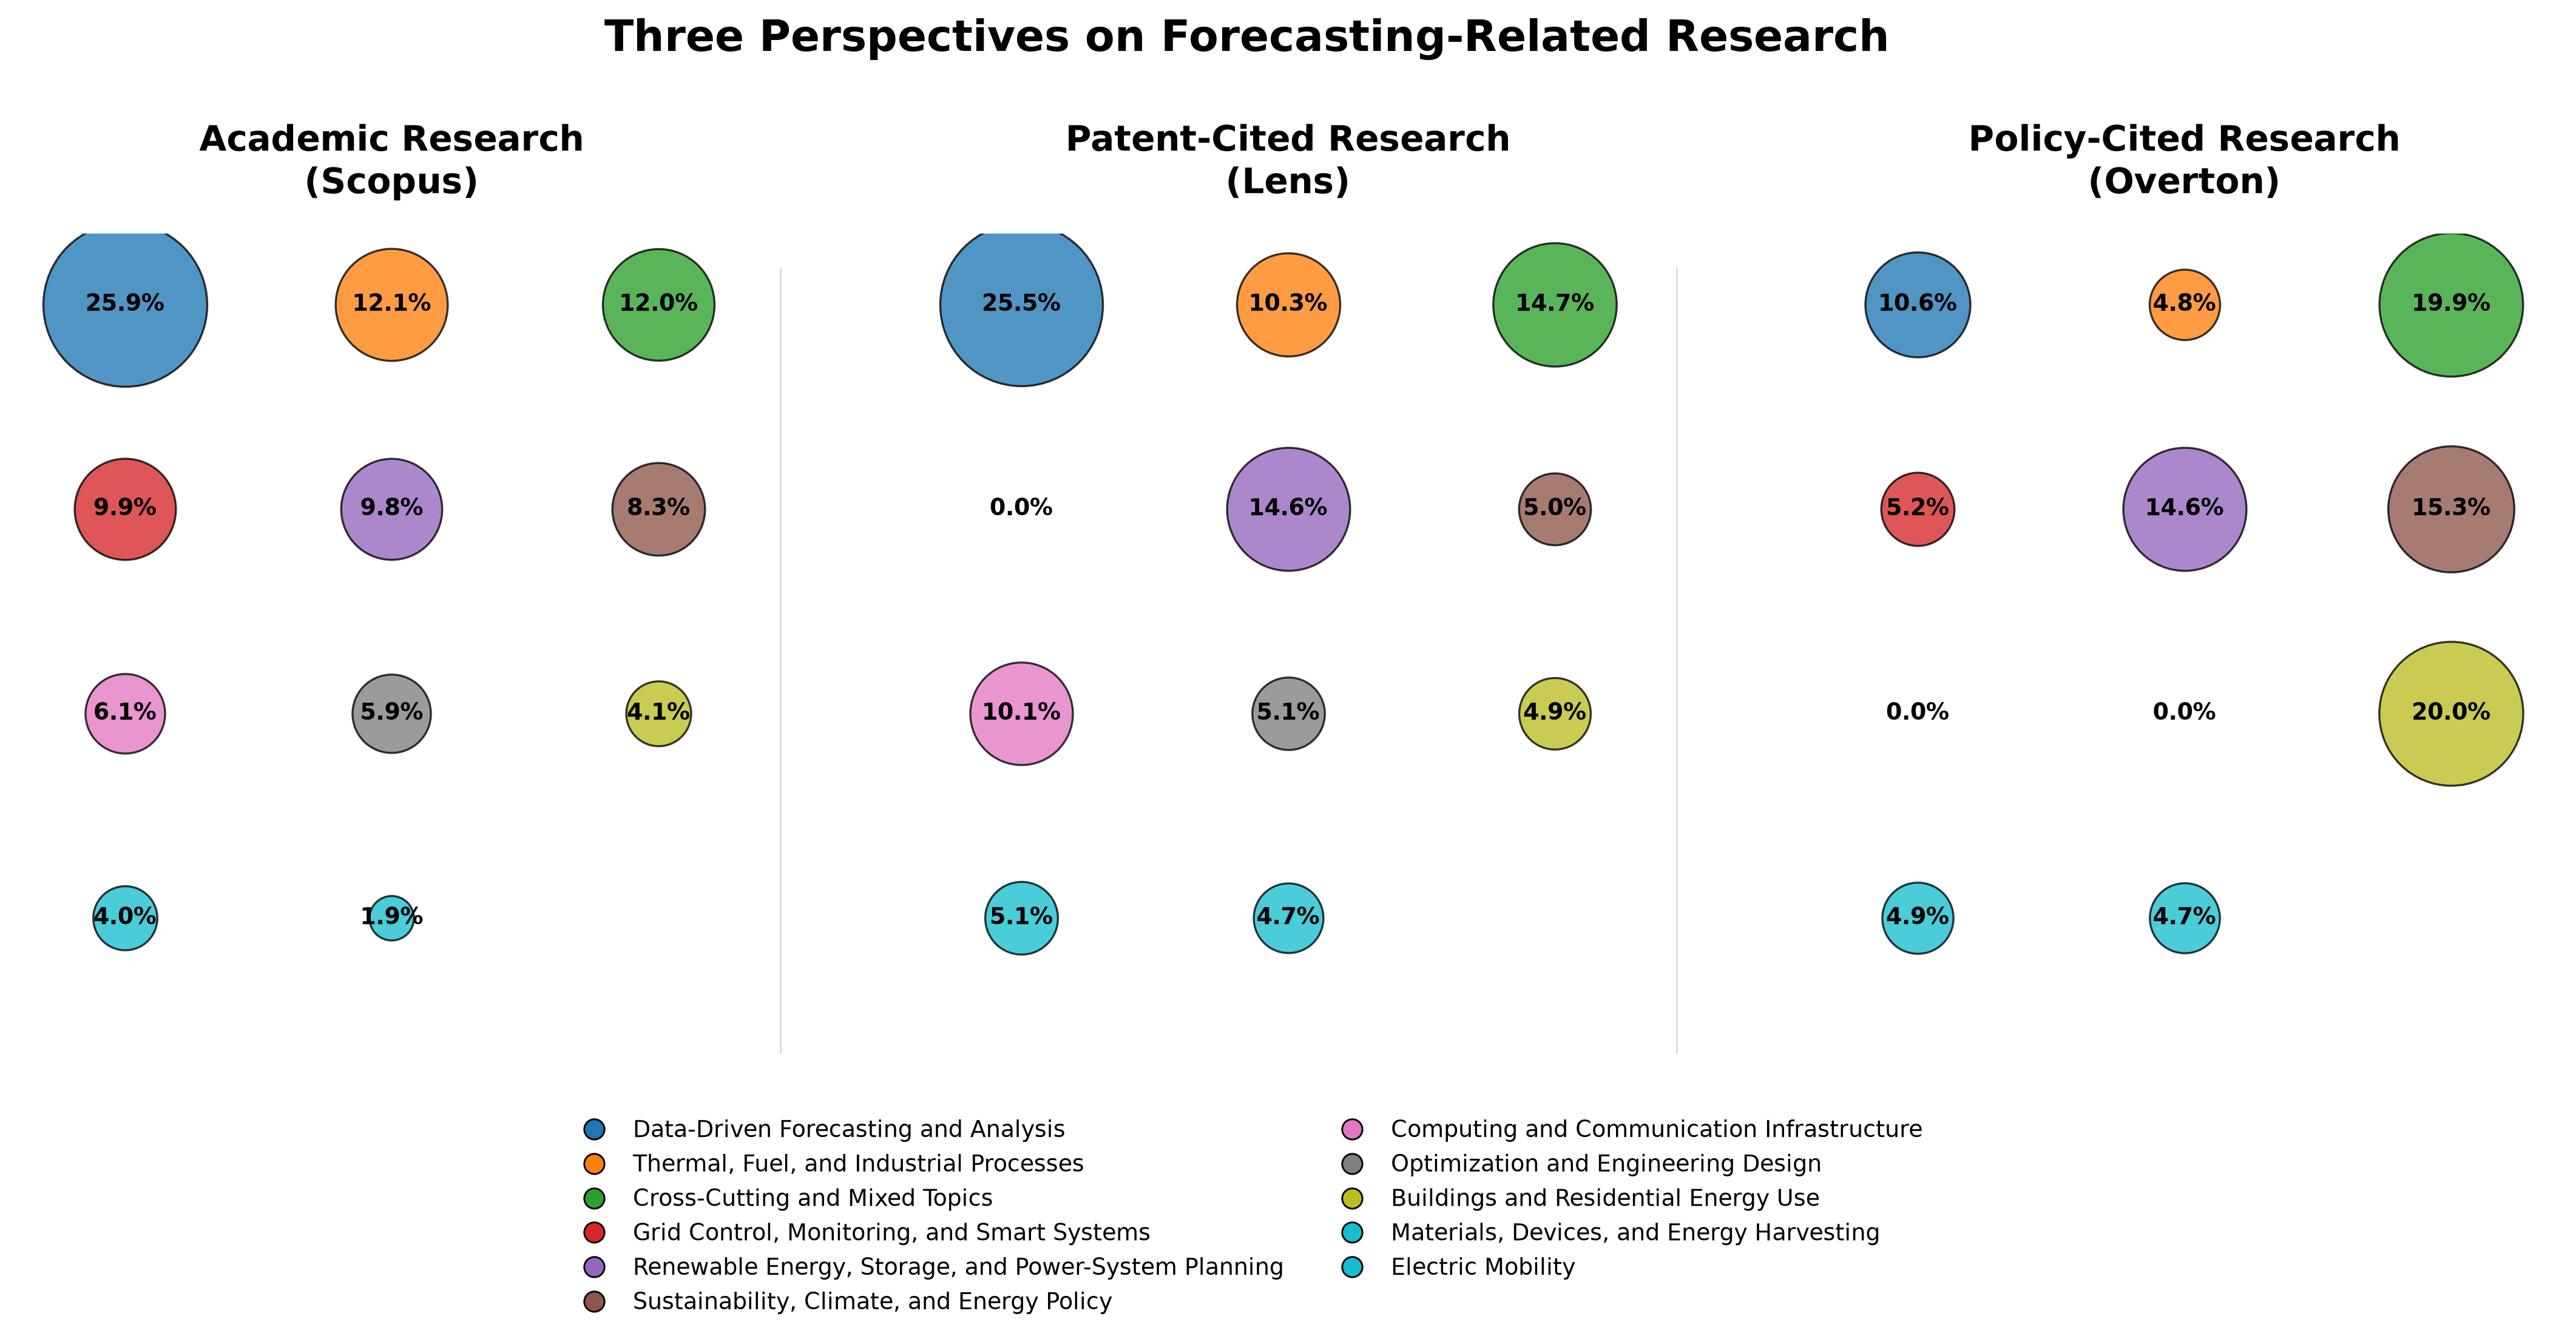

In [132]:
# ---------------------------------------------------------
# 10.4 Three-perspective thematic bubble landscape
# ---------------------------------------------------------

perspective_config = {

    "Academic": {
        "column": "Academic_Prevalence",
        "title": "Academic Research",
        "subtitle": "Scopus",
    },

    "Patent": {
        "column": "Patent_Prevalence",
        "title": "Patent-Cited Research",
        "subtitle": "Lens",
    },

    "Policy": {
        "column": "Policy_Prevalence",
        "title": "Policy-Cited Research",
        "subtitle": "Overton",
    },
}

fig, axes = plt.subplots(
    1,
    3,
    figsize=(
        18,
        7.2,
    ),
    dpi=300,
)


# ---------------------------------------------------------
# Bubble scaling
# ---------------------------------------------------------

all_prevalence = np.concatenate(
    [
        three_perspective_themes[
            config["column"]
        ]
        .to_numpy(
            dtype=float
        )

        for config
        in perspective_config.values()
    ]
)


max_prevalence = (
    all_prevalence.max()
)


MAX_BUBBLE_AREA = 4200


for ax in axes[:-1]:

    ax.plot(
        [1.02, 1.02],
        [0.04, 0.96],
        transform=ax.transAxes,
        clip_on=False,
        linewidth=0.6,
        alpha=0.25,
    )

for ax, (
    perspective,
    config,
) in zip(
    axes,
    perspective_config.items(),
):

    prevalence_column = (
        config[
            "column"
        ]
    )


    for _, row in (
        three_perspective_themes
        .iterrows()
    ):

        theme = (
            row[
                "Common_Macro_Theme"
            ]
        )

        prevalence = float(
            row[
                prevalence_column
            ]
        )


        x, y = (
            THEME_POSITIONS[
                theme
            ]
        )


        # Bubble area proportional to prevalence.
        bubble_area = (
            prevalence
            /
            max_prevalence
            *
            MAX_BUBBLE_AREA
        )


        ax.scatter(
            x,
            y,
            s=bubble_area,
            color=THEME_COLORS[
                theme
            ],
            alpha=0.78,
            edgecolors="black",
            linewidths=0.8,
            zorder=2,
        )


        # Percentage in bubble center.
        ax.text(
            x,
            y,
            f"{prevalence:.1f}%",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            zorder=3,
        )


    ax.set_xlim(
        -2.1,
        2.1,
    )

    ax.set_ylim(
        -2.75,
        2.05,
    )


    ax.set_aspect(
        "equal"
    )


    ax.set_xticks([])
    ax.set_yticks([])


    for spine in (
        ax.spines.values()
    ):

        spine.set_visible(
            False
        )


    ax.set_title(
        (
            f"{config['title']}\n"
            f"({config['subtitle']})"
        ),
        fontsize=14,
        fontweight="bold",
        pad=16,
    )

# ---------------------------------------------------------
# 10.5 Common macro-theme legend
# ---------------------------------------------------------

THEME_LEGEND_LABELS = {theme: theme for theme in COMMON_MACRO_THEMES}

legend_handles = [

    plt.Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor=THEME_COLORS[theme],
        markeredgecolor="black",
        markeredgewidth=0.7,
        markersize=8,
        label=THEME_LEGEND_LABELS[theme],
    )

    for theme in COMMON_MACRO_THEMES
]

fig.suptitle(
    "Three Perspectives on Forecasting-Related Research",
    fontsize=17,
    fontweight="bold",
    y=0.985,
)

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False,
    fontsize=9,
    columnspacing=2.0,
    handletextpad=0.7,
)

In [134]:
# ---------------------------------------------------------
# 10.6 Figure export
# ---------------------------------------------------------

THREE_PERSPECTIVE_BUBBLE_FIGURE = (
    COMPARISON_FIGURE_DIR
    / "academic_patent_policy_thematic_landscape.pdf"
)


fig.savefig(
    THREE_PERSPECTIVE_BUBBLE_FIGURE,
    format="pdf",
    bbox_inches="tight",
)


print(
    "Saved:",
    THREE_PERSPECTIVE_BUBBLE_FIGURE
)


plt.show()

Saved: /nfs/mfirdausi/project/review_paper_fahruddin/output/academic_patent_policy_comparison/figures/academic_patent_policy_thematic_landscape.pdf


## 11. Three-Perspective Bubble Matrix

To complement the thematic landscape, a bubble matrix provides a more
structured comparison of macro-theme prevalence across the academic,
patent-cited, and policy-cited perspectives.

Rows represent the common macro-themes and columns represent the three
research perspectives. Bubble area is proportional to probability-weighted
macro-theme prevalence, while the numerical value inside each bubble reports
the corresponding percentage.

Unlike the thematic landscape, the matrix emphasizes direct row-wise
comparison and therefore makes thematic amplification, attenuation, and
cross-perspective consistency easier to identify.

In [135]:
# ---------------------------------------------------------
# 11.1 Prepare bubble-matrix data
# ---------------------------------------------------------

bubble_matrix_data = (
    three_perspective_long
    .copy()
)


# Preserve canonical theme order.
bubble_matrix_data[
    "Common_Macro_Theme"
] = pd.Categorical(
    bubble_matrix_data[
        "Common_Macro_Theme"
    ],
    categories=COMMON_MACRO_THEMES,
    ordered=True,
)


# Explicit perspective order.
PERSPECTIVE_ORDER = [
    "Academic",
    "Patent",
    "Policy",
]


bubble_matrix_data[
    "Perspective"
] = pd.Categorical(
    bubble_matrix_data[
        "Perspective"
    ],
    categories=PERSPECTIVE_ORDER,
    ordered=True,
)


bubble_matrix_data = (
    bubble_matrix_data
    .sort_values(
        [
            "Common_Macro_Theme",
            "Perspective",
        ]
    )
    .reset_index(
        drop=True
    )
)


display(
    bubble_matrix_data
)

,Common_Macro_Theme,Perspective,Prevalence_Percent
0,Data-Driven Forecasting and Analysis,Academic,25.893867
1,Data-Driven Forecasting and Analysis,Patent,25.525160
2,Data-Driven Forecasting and Analysis,Policy,10.624681
3,"Thermal, Fuel, and Industrial Processes",Academic,12.113878
4,"Thermal, Fuel, and Industrial Processes",Patent,10.271131
5,"Thermal, Fuel, and Industrial Processes",Policy,4.783447
6,Cross-Cutting and Mixed Topics,Academic,12.023355
7,Cross-Cutting and Mixed Topics,Patent,14.695798
8,Cross-Cutting and Mixed Topics,Policy,19.882327
9,"Grid Control, Monitoring, and Smart Systems",Academic,9.878849


In [136]:
# ---------------------------------------------------------
# 11.2 Compact row labels
# ---------------------------------------------------------

import textwrap

BUBBLE_MATRIX_LABELS = {
    theme: textwrap.fill(theme, width=32)
    for theme in COMMON_MACRO_THEMES
}

In [137]:
# ---------------------------------------------------------
# 11.6 Save bubble matrix
# ---------------------------------------------------------

THREE_PERSPECTIVE_MATRIX_FIGURE = (
    COMPARISON_FIGURE_DIR
    / "academic_patent_policy_bubble_matrix.pdf"
)


fig.savefig(
    THREE_PERSPECTIVE_MATRIX_FIGURE,
    format="pdf",
    bbox_inches="tight",
)


print(
    "Saved:",
    THREE_PERSPECTIVE_MATRIX_FIGURE
)


plt.show()

Saved: /nfs/mfirdausi/project/review_paper_fahruddin/output/academic_patent_policy_comparison/figures/academic_patent_policy_bubble_matrix.pdf


## 12. Heatmap / Bubble Matrix

## 13. Export Manuscript Tables and Figures

## 14. Reproducibility Checks